
# Validate gene signature in external study with TNF inhibitor treatment
- Farutin et al. https://arthritis-research.biomedcentral.com/articles/10.1186/s13075-019-1999-3

In [ ]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library("Seurat")
quiet_library("tidyverse")
quiet_library("data.table")
quiet_library("ggplot2")
quiet_library("Matrix")
quiet_library("dplyr")
quiet_library("viridis")
quiet_library("future.apply")
quiet_library("scran")
quiet_library("SingleCellExperiment")
quiet_library("DESeq2")
quiet_library("GEOquery")
quiet_library("ggpubr")
quiet_library("broom")


Warning message:
“Failed to locate timezone database”


In [ ]:
# define the color palette to be used
npg_color <- c(
    "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
    "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
npg_color_ext <- colorRampPalette(npg_color)(15)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
    "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)


In [ ]:
# define working path
data_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/TNFi/GSE129705"
meta_path <- "/home/workspace/github/ra-longitudinal/metadata"
fig_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/TNFi/figures"
output_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/TNFi/GSE129705/results"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
proj_name <- "ALTRA_AIM3_scRNA_tnfi_validation_"


In [ ]:
run_mcnemar_test <- function(x) {
    cont_counts <- x %>%
        pivot_wider(
            id_cols = aim3_direction,
            names_from = tnfi_direction, values_from = n
        )
    # print(cont_counts)
    test_res <- rstatix::mcnemar_test(cont_counts %>% select(-aim3_direction)) %>% as_tibble()
    return(test_res)
}


# download data from GEO


In [ ]:
# Specify GEO Accession ID
gse_id <- "GSE129705" # Replace with the desired GEO ID

# Download the GEO dataset
gse <- getGEO(gse_id, GSEMatrix = TRUE) # Set GSEMatrix = TRUE for a structured format


Found 1 file(s)

GSE129705_series_matrix.txt.gz



In [ ]:
gse


$GSE129705_series_matrix.txt.gz
ExpressionSet (storageMode: lockedEnvironment)
assayData: 0 features, 128 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: GSM3720523 GSM3720524 ... GSM3720650 (128 total)
  varLabels: title geo_accession ... visit_time:ch1 (49 total)
  varMetadata: labelDescription
featureData: none
experimentData: use 'experimentData(object)'
  pubMedIds: 31647025 
Annotation: GPL16791 


In [ ]:
# Extract metadata for all samples
sample_metadata <- pData(gse[[1]])
sample_metadata %>% write_csv(file.path(data_path, paste0(gse_id, "_sample_metadata.csv")))


In [ ]:
# select sample metadata
sample_metadata_fl <- sample_metadata %>%
    select(title, geo_accession, `ccp_status_bl:ch1`:`visit_time:ch1`) %>%
    rename("title" = "sample")
colnames(sample_metadata_fl) <- colnames(sample_metadata_fl) %>% str_remove(":ch1")
sample_metadata_fl %>% head()


,sample,geo_accession,ccp_status_bl,cohort,eular_response,rf_status_bl,subject status,subject_id,visit_time
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM3720523,C1-43-MO3,GSM3720523,neg,Cohort 1,None,pos,naive rheumatoid arthritis patient,C1.43,MONTH 3
GSM3720524,C1-80-BL,GSM3720524,pos,Cohort 1,Good,pos,naive rheumatoid arthritis patient,C1.80,BASELINE
GSM3720525,C1-76-BL,GSM3720525,pos,Cohort 1,None,neg,naive rheumatoid arthritis patient,C1.76,BASELINE
GSM3720526,C1-119-BL,GSM3720526,pos,Cohort 1,Good,pos,naive rheumatoid arthritis patient,C1.119,BASELINE
GSM3720527,C1-52-BL,GSM3720527,neg,Cohort 1,Good,pos,naive rheumatoid arthritis patient,C1.52,BASELINE
GSM3720528,C1-99-BL,GSM3720528,pos,Cohort 1,Good,pos,naive rheumatoid arthritis patient,C1.99,BASELINE


In [ ]:
# load gex data
# GSE229449 = read_tsv(file.path(data_path, 'GSE229449_processed_data_matrix.txt'))
GSE129705 <- read_tsv(file.path(data_path, "GSE129705_c12-ra-wb-bl-mo3-processed-data-file.txt"))


Rows: 25370 Columns: 134
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (5): Geneid, Chr, Start, End, Strand
dbl (129): Length, C1-43-MO3, C1-80-BL, C1-76-BL, C1-119-BL, C1-52-BL, C1-99...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
GSE129705 %>% head()


Geneid,Chr,Start,End,Strand,Length,C1-43-MO3,C1-80-BL,C1-76-BL,C1-119-BL,⋯,C2-6-MO3,C2-33-BL,C2-64-BL,C2-94-BL,C2-46-BL,C2-62-BL,C2-46-MO3,C2-63-MO3,C2-6-BL,C2-43-BL
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DDX11L1,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,0,0,0,⋯,3,1,16,0,0,23,1,2,3,6
WASH7P,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,127,145,425,22,⋯,245,235,635,164,478,368,402,275,373,227
MIR6859-2,chr1;chr15;chr16,17369;102513727;67052,17436;102513794;67119,-;+;-,204,157,55,56,35,⋯,60,58,115,28,129,80,123,59,103,31
MIR6859-1,chr1;chr15;chr16,17369;102513727;67052,17436;102513794;67119,-;+;-,204,157,55,56,35,⋯,60,58,115,28,129,80,123,59,103,31
FAM138A,chr1;chr1;chr1;chr19;chr19;chr19,34611;35277;35721;76220;76886;77330,35174;35481;36081;76783;77090;77690,-;-;-;-;-;-,2260,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
FAM138F,chr1;chr1;chr1;chr19;chr19;chr19,34611;35277;35721;76220;76886;77330,35174;35481;36081;76783;77090;77690,-;-;-;-;-;-,2260,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [ ]:
GSE129705 %>% dim()


[1] 25370   134

In [ ]:
GSE129705 %>% janitor::get_dupes(Geneid)


No duplicate combinations found of: Geneid

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


Geneid,dupe_count,Chr,Start,End,Strand,Length,C1-43-MO3,C1-80-BL,C1-76-BL,⋯,C2-6-MO3,C2-33-BL,C2-64-BL,C2-94-BL,C2-46-BL,C2-62-BL,C2-46-MO3,C2-63-MO3,C2-6-BL,C2-43-BL
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


## construct data input for DEseq2


In [ ]:
# construct count matrix
counts <- GSE129705 %>%
    select(-c(Geneid:Length)) %>%
    as.matrix()
rownames(counts) <- GSE129705$Geneid


In [ ]:
counts[1:5, 1:5]


,C1-43-MO3,C1-80-BL,C1-76-BL,C1-119-BL,C1-52-BL
DDX11L1,0,0,0,0,0
WASH7P,127,145,425,22,173
MIR6859-2,157,55,56,35,107
MIR6859-1,157,55,56,35,107
FAM138A,0,0,0,0,0


In [ ]:
# double check the sample id matches
table(colnames(counts) %in% sample_metadata_fl$sample)
table(sample_metadata_fl$sample %in% colnames(counts))
all(sample_metadata_fl$sample == colnames(counts))
# counts <- counts %>% select(sample_metadata_fl$sample)



TRUE 
 128 


TRUE 
 128 

[1] TRUE

In [ ]:
sample_metadata_fl %>% head()


,sample,geo_accession,ccp_status_bl,cohort,eular_response,rf_status_bl,subject status,subject_id,visit_time
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM3720523,C1-43-MO3,GSM3720523,neg,Cohort 1,None,pos,naive rheumatoid arthritis patient,C1.43,MONTH 3
GSM3720524,C1-80-BL,GSM3720524,pos,Cohort 1,Good,pos,naive rheumatoid arthritis patient,C1.80,BASELINE
GSM3720525,C1-76-BL,GSM3720525,pos,Cohort 1,None,neg,naive rheumatoid arthritis patient,C1.76,BASELINE
GSM3720526,C1-119-BL,GSM3720526,pos,Cohort 1,Good,pos,naive rheumatoid arthritis patient,C1.119,BASELINE
GSM3720527,C1-52-BL,GSM3720527,neg,Cohort 1,Good,pos,naive rheumatoid arthritis patient,C1.52,BASELINE
GSM3720528,C1-99-BL,GSM3720528,pos,Cohort 1,Good,pos,naive rheumatoid arthritis patient,C1.99,BASELINE


In [ ]:
sample_metadata_fl %>%
    group_by(eular_response) %>%
    tally()


eular_response,n
<chr>,<int>
Good,72
None,56


In [ ]:
## construct deseq2 object
sample_metadata_dds <- sample_metadata_fl %>%
    as_tibble(rownames = "geo_id") %>%
    mutate(cohort = factor(cohort))
dds <- DESeqDataSetFromMatrix(counts, sample_metadata_dds, ~ subject_id + visit_time)


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [ ]:
dds


class: DESeqDataSet 
dim: 25370 128 
metadata(1): version
assays(1): counts
rownames(25370): DDX11L1 WASH7P ... GOLGA2P3Y GOLGA2P2Y
rowData names(0):
colnames(128): C1-43-MO3 C1-80-BL ... C2-6-BL C2-43-BL
colData names(10): geo_id sample ... subject_id visit_time

In [ ]:
# sample_metadata_fl%>%filter(eular_response=='None')%>%
#     group_by(subject_id)%>%tally()%>%
#     filter(n>=2)


## run analysis in responder


In [ ]:
# only keep paired analysis in responder
resp_paired_subj <- sample_metadata_fl %>%
    filter(eular_response == "Good") %>%
    group_by(subject_id) %>%
    tally() %>%
    filter(n >= 2) %>%
    pull(subject_id)
resp_pair_metadata <- sample_metadata_fl %>% filter(subject_id %in% resp_paired_subj)
dds_resp_pair <- dds[, colData(dds)$sample %in% resp_pair_metadata$sample]
dds_resp_pair


class: DESeqDataSet 
dim: 25370 64 
metadata(1): version
assays(1): counts
rownames(25370): DDX11L1 WASH7P ... GOLGA2P3Y GOLGA2P2Y
rowData names(0):
colnames(64): C1-80-BL C1-119-BL ... C2-46-MO3 C2-6-BL
colData names(10): geo_id sample ... subject_id visit_time

In [ ]:
# resp_pair_metadata%>%arrange(subject_id, visit_time)


In [ ]:
# filter gene
smallestGroupSize <- 32
keep <- rowSums(counts(dds_resp_pair) >= 10) >= smallestGroupSize
dds_resp_pair <- dds_resp_pair[keep, ]
dds_resp_pair


class: DESeqDataSet 
dim: 13507 64 
metadata(1): version
assays(1): counts
rownames(13507): WASH7P MIR6859-2 ... TMLHE CD24
rowData names(0):
colnames(64): C1-80-BL C1-119-BL ... C2-46-MO3 C2-6-BL
colData names(10): geo_id sample ... subject_id visit_time

In [ ]:
# set factor
dds_resp_pair$visit_time <- factor(dds_resp_pair$visit_time, levels = c("BASELINE", "MONTH 3"))
dds_resp_pair$subject_id <- factor(dds_resp_pair$subject_id)


In [ ]:
# run DEseq2
dds_resp_pair <- DESeq(dds_resp_pair)
dds_resp_pair_res <- results(dds_resp_pair)


estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [ ]:
# get the results
dds_resp_pair_res_tb <- dds_resp_pair_res %>%
    as_tibble(rownames = "gene") %>%
    mutate(q_values = qvalue::qvalue(pvalue)$qvalues) %>%
    select(-padj)
dds_resp_pair_res_tb %>% head()


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WASH7P,282.46281,-0.09281714,0.1579898,-0.5874882,5.568758e-01,0.3940484244
MIR6859-2,82.43028,-0.09276267,0.1202438,-0.7714549,4.404374e-01,0.3476168954
MIR6859-1,82.43028,-0.09276267,0.1202438,-0.7714549,4.404374e-01,0.3476168954
LOC729737,5237.19115,-0.63263934,0.1486966,-4.2545639,2.094568e-05,0.0007281225
LOC100132287,56.49217,-0.28869491,0.2721108,-1.0609461,2.887144e-01,0.2736714593
LOC100133331,894.93107,-0.36483483,0.1755931,-2.0777282,3.773440e-02,0.0858577496


In [ ]:
# save the deg table
dds_resp_pair_res_tb %>% write_csv(file.path(output_path, paste0(proj_name, "_responder_pre_post_degs.csv")))


In [ ]:
# load the deg table
dds_resp_pair_res_tb <- read_csv(file.path(output_path, paste0(proj_name, "_responder_pre_post_degs.csv")))


Rows: 13507 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): gene
dbl (6): baseMean, log2FoldChange, lfcSE, stat, pvalue, q_values

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


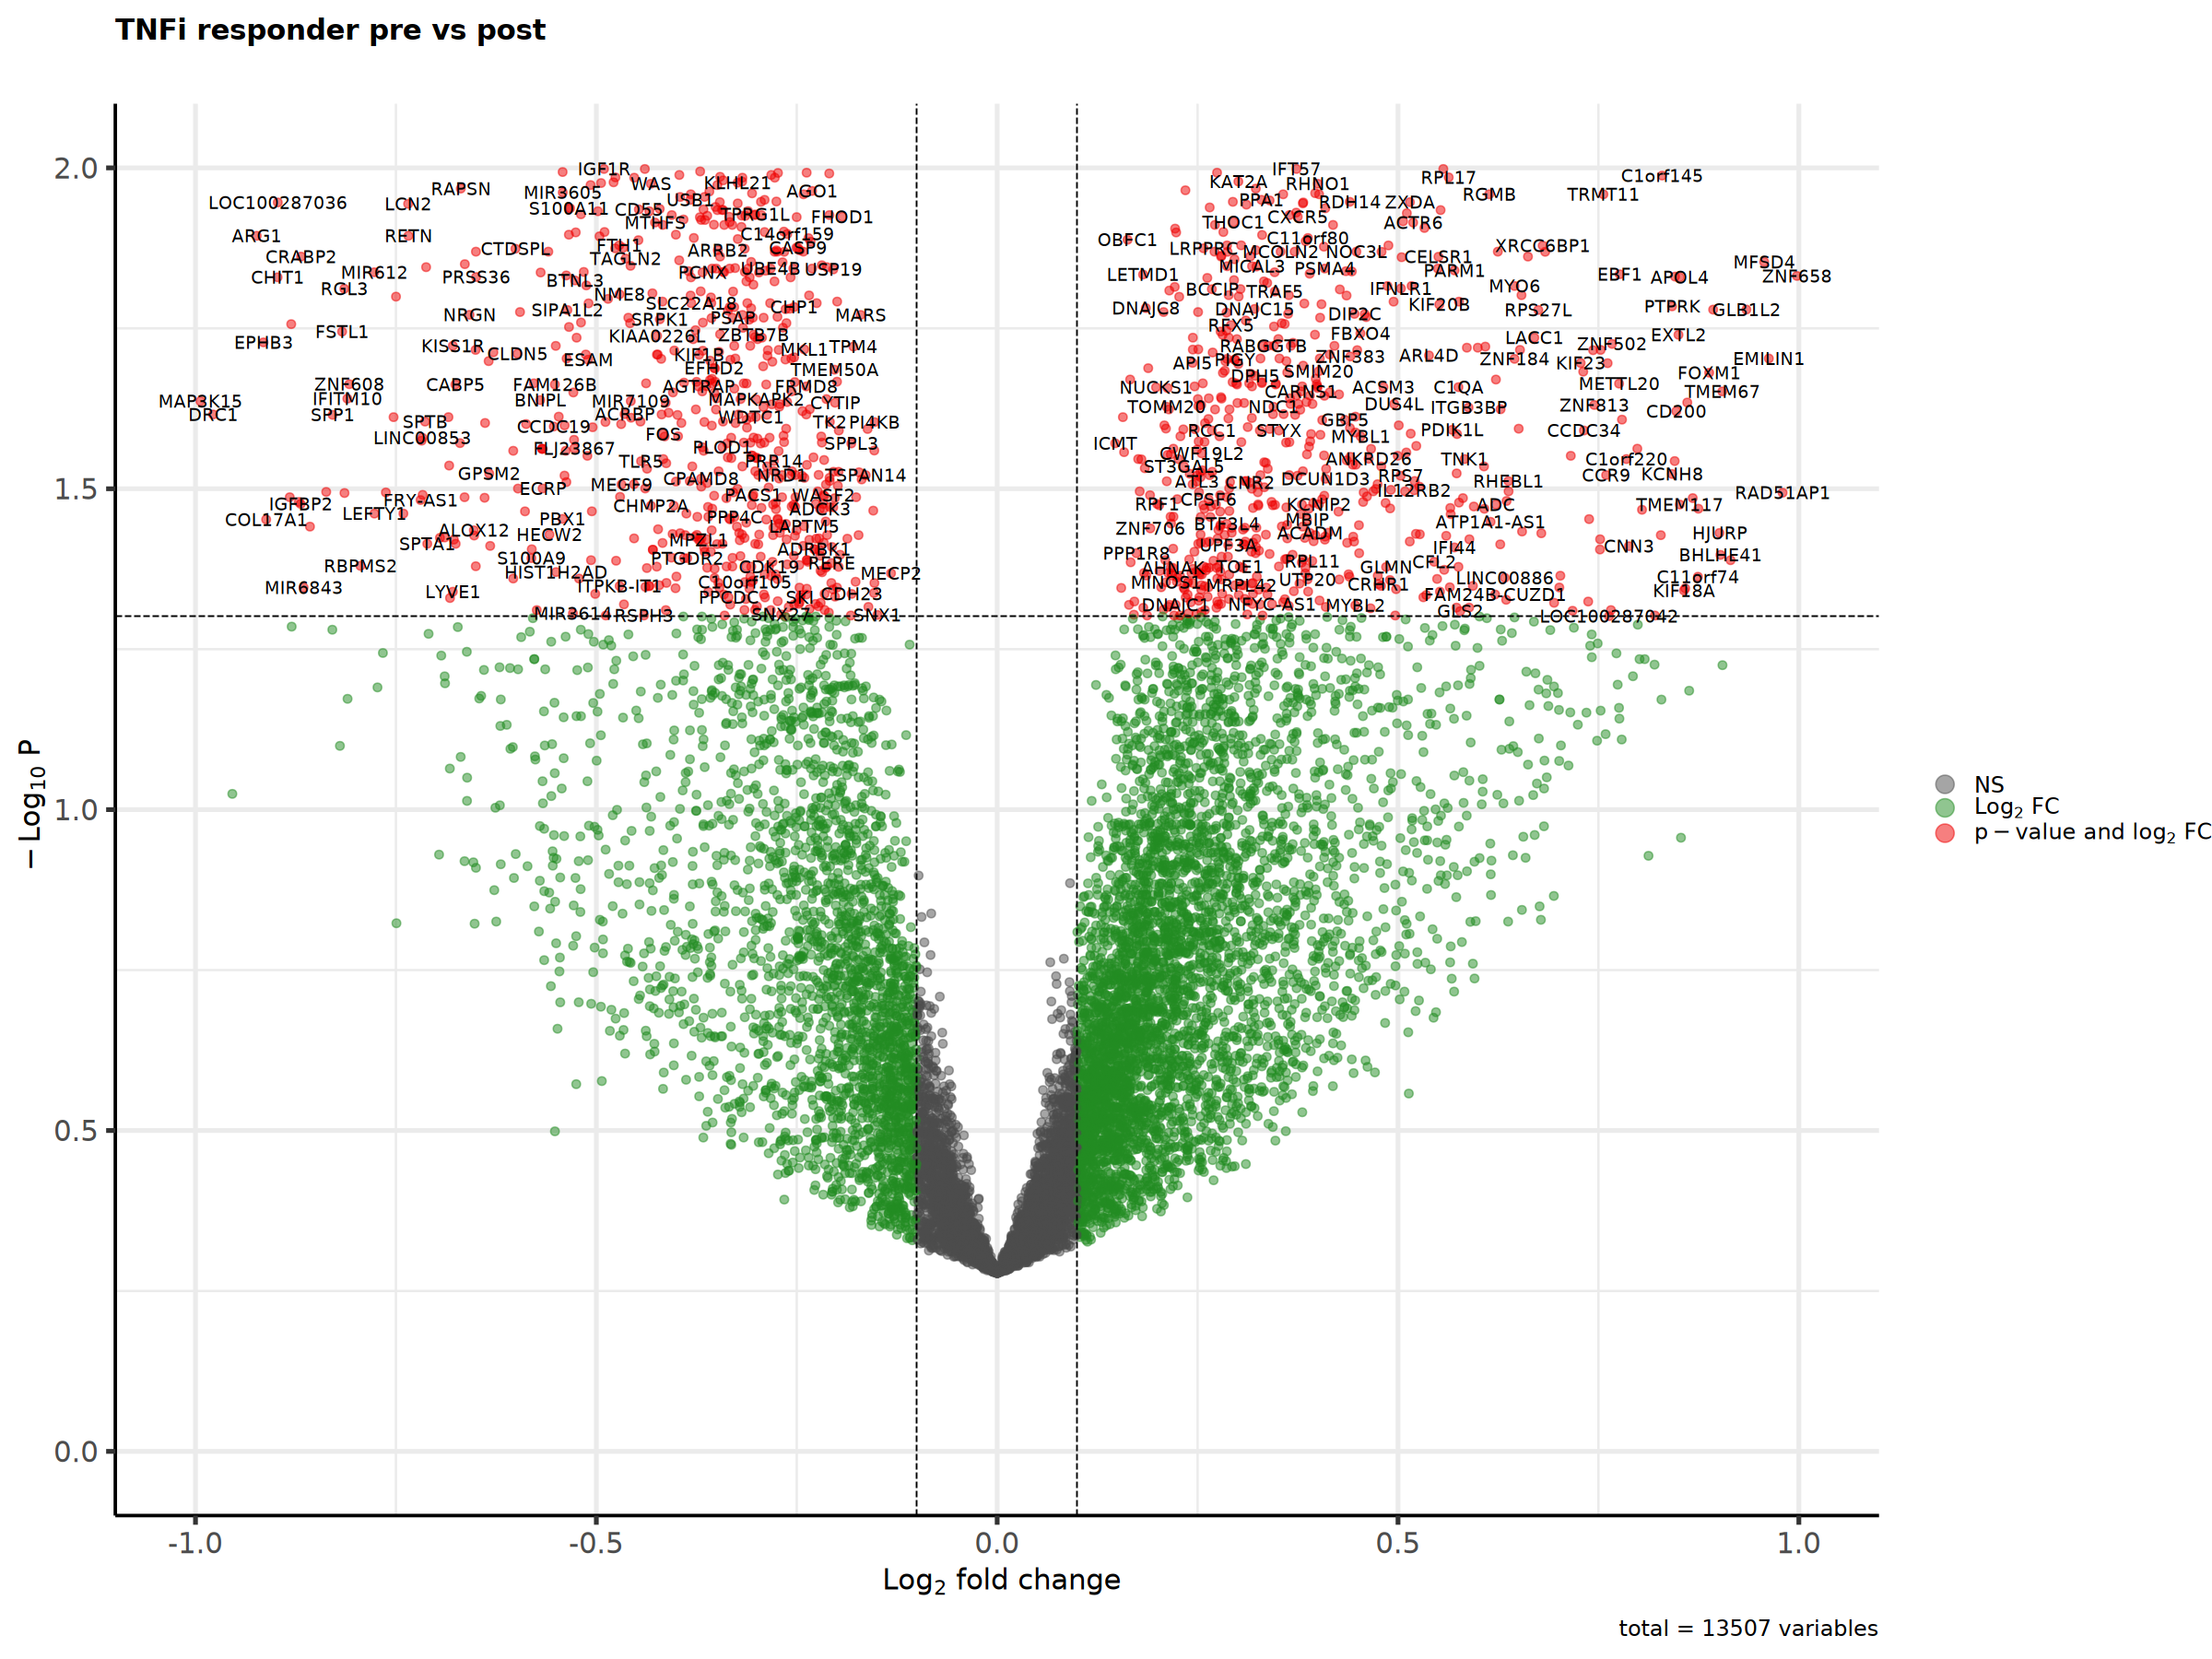

In [ ]:
# Plot the DA results for aim1
p1 <- EnhancedVolcano::EnhancedVolcano(dds_resp_pair_res_tb,
    title = "TNFi responder pre vs post",
    subtitle = "",
    lab = dds_resp_pair_res_tb$gene,
    x = "log2FoldChange",
    y = "q_values",
    pCutoff = 0.05,
    FCcutoff = 0.1,
    pointSize = 2.0, # drawConnectors = TRUE,
    widthConnectors = 1.0,
    colConnectors = "black", legendPosition = "right",
    arrowheads = FALSE,
    labSize = 4.0
) +
    xlim(c(-1, 1)) + ylim(0, 2)
p1
ggsave(file.path(fig_path, paste0(proj_name, "_prevspost_valcano_plot.png")),
    width = 8, height = 6
)


In [ ]:
fig_path


[1] "/home/workspace/private/ra-cohort-ide/ALTRA_revision/TNFi/figures"

### load aim3 degs results and compared with the responder


In [ ]:
data_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results"
# load aim3 deg
aim3_degs <- read_csv(
    file.path(file.path(
        data_path,
        "ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3_mixed_models_time_result_750days.csv"
    )),
    show_col_types = FALSE
) %>%
    dplyr::rename("cell_type" = "celltype")


In [ ]:
# combine the deg results
tnfi_aim3_degs_comparison <- dds_resp_pair_res_tb %>%
      full_join(aim3_degs,
            by = c("gene"),
            suffix = c("_tnfi", "_aim3")
      ) %>%
      dplyr::rename("pvalue_aim3" = "p.value") %>%
      filter(q_values_aim3 < 0.1 & # padj<0.1&
            !is.na(log2FoldChange)) %>%
      mutate(sig = case_when(
            q_values_tnfi <= 0.1 & q_values_aim3 <= 0.1 ~ "tnfiSig&Aim3Sig",
            q_values_tnfi > 0.1 & q_values_aim3 <= 0.1 ~ "Aim3Sig",
            q_values_tnfi <= 0.1 & q_values_aim3 > 0.1 ~ "tnfiSig",
            q_values_tnfi > 0.1 & q_values_aim3 > 0.1 ~ "No sig"
      )) %>%
      mutate(
            aim3_direction = if_else(estimate > 0, "aim3_up", "aim3_down"),
            tnfi_direction = if_else(log2FoldChange > 0, "tnfi_up", "tnfi_down")
      )
tnfi_aim3_degs_comparison %>% colnames()


[1] "gene"           "baseMean"       "log2FoldChange" "lfcSE"         
 [5] "stat"           "pvalue"         "q_values_tnfi"  "cell_type"     
 [9] "effect"         "group"          "term"           "estimate"      
[13] "std.error"      "statistic"      "df"             "pvalue_aim3"   
[17] "q_values_aim3"  "sig"            "aim3_direction" "tnfi_direction"

### run a HyperGeometric Enrichment test


In [ ]:
quiet_library("hypeR")


In [ ]:
# check the deg counts
aim3_degs_counts <- aim3_degs %>%
    mutate(sig_0_1 = if_else(q_values < 0.1, "sig", "ns")) %>%
    group_by(cell_type) %>%
    mutate(total_genes = n()) %>%
    group_by(cell_type, sig_0_1) %>%
    summarise(counts = n(), total_genes = unique(total_genes))
aim3_degs_counts %>% filter(cell_type %in% c("Core naive CD4 T cell", "CM CD4 T cell"))


`summarise()` has grouped output by 'cell_type'. You can override using the
`.groups` argument.


cell_type,sig_0_1,counts,total_genes
<chr>,<chr>,<int>,<int>
CM CD4 T cell,ns,2785,5497
CM CD4 T cell,sig,2712,5497
Core naive CD4 T cell,ns,2299,4950
Core naive CD4 T cell,sig,2651,4950


In [ ]:
# use tnfi response genes as the reference
# check if the aim3 degs are significant enriched.
celltype_test <- "Core naive CD4 T cell"
aim3_sig_genes <- aim3_degs %>%
    filter(cell_type == celltype_test & q_values < 0.1) %>%
    pull(gene)
aim3_bg_genes <- aim3_degs %>%
    filter(cell_type == celltype_test) %>%
    pull(gene)

tnfi_sig_genes <- dds_resp_pair_res_tb %>%
    filter(q_values < 0.1) %>%
    pull(gene)
tnfi_genes_list <- list("tnfi_responder_genes" = tnfi_sig_genes)

hyp_obj <- hypeR(aim3_sig_genes, tnfi_genes_list,
    test = "hypergeometric", background = length(aim3_bg_genes), plotting = TRUE
)
hyp_obj


(hyp) 

  data: 
                label pval fdr signature geneset overlap background
 tnfi_responder_genes    1   1      2651    3420     580       4950
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [ ]:
# make a degs list per cell type
celltypes_test <- aim3_degs %>%
    filter(q_values < 0.1) %>%
    group_by(cell_type) %>%
    tally() %>%
    filter(n > 10) %>%
    pull(cell_type) %>%
    unique()
aim3_genes_list <- lapply(celltypes_test, function(x) {
    sig_genes <- aim3_degs %>%
        filter(cell_type == x & q_values < 0.1) %>%
        pull(gene)
    return(sig_genes)
})

names(aim3_genes_list) <- celltypes_test
# aim3_genes_list
tnfi_sig_genes <- dds_resp_pair_res_tb %>%
    filter(q_values < 0.1) %>%
    pull(gene)
tnfi_bg_genes <- dds_resp_pair_res_tb %>% pull(gene)

hyp_obj <- hypeR(tnfi_sig_genes, aim3_genes_list,
    test = "hypergeometric", background = length(tnfi_bg_genes), plotting = TRUE
)


In [ ]:
hyp_to_excel(hyp_obj, file_path = file.path(data_path, "pathways.xlsx"))


In [ ]:
## plot fig6E
hyp_obj$data


label                            pval fdr
GZMK+ CD27+ EM CD8 T cell        GZMK+ CD27+ EM CD8 T cell        0.14 1  
Core naive B cell                Core naive B cell                0.47 1  
Core naive CD8 T cell            Core naive CD8 T cell            0.59 1  
CM CD8 T cell                    CM CD8 T cell                    0.64 1  
Naive CD4 Treg                   Naive CD4 Treg                   0.74 1  
KLRF1+ GZMB+ CD27- EM CD8 T cell KLRF1+ GZMB+ CD27- EM CD8 T cell 0.97 1  
KLRF1- GZMB+ CD27- EM CD8 T cell KLRF1- GZMB+ CD27- EM CD8 T cell 0.97 1  
CM CD4 T cell                    CM CD4 T cell                    1.00 1  
Core naive CD4 T cell            Core naive CD4 T cell            1.00 1  
                                 signature geneset overlap background
GZMK+ CD27+ EM CD8 T cell        3420        59     19     13507     
Core naive B cell                3420        45     12     13507     
Core naive CD8 T cell            3420       305     76     13507     
CM CD8 T cell                    3420        46     11     13507     
Naive CD4 Treg                   3420        32      7     13507     
KLRF1+ GZMB+ CD27- EM CD8 T cell 3420       209     42     13507     
KLRF1- GZMB+ CD27- EM CD8 T cell 3420       181     36     13507     
CM CD4 T cell                    3420      2712    622     13507     
Core naive CD4 T cell            3420      2651    580     13507     
                                 hits                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

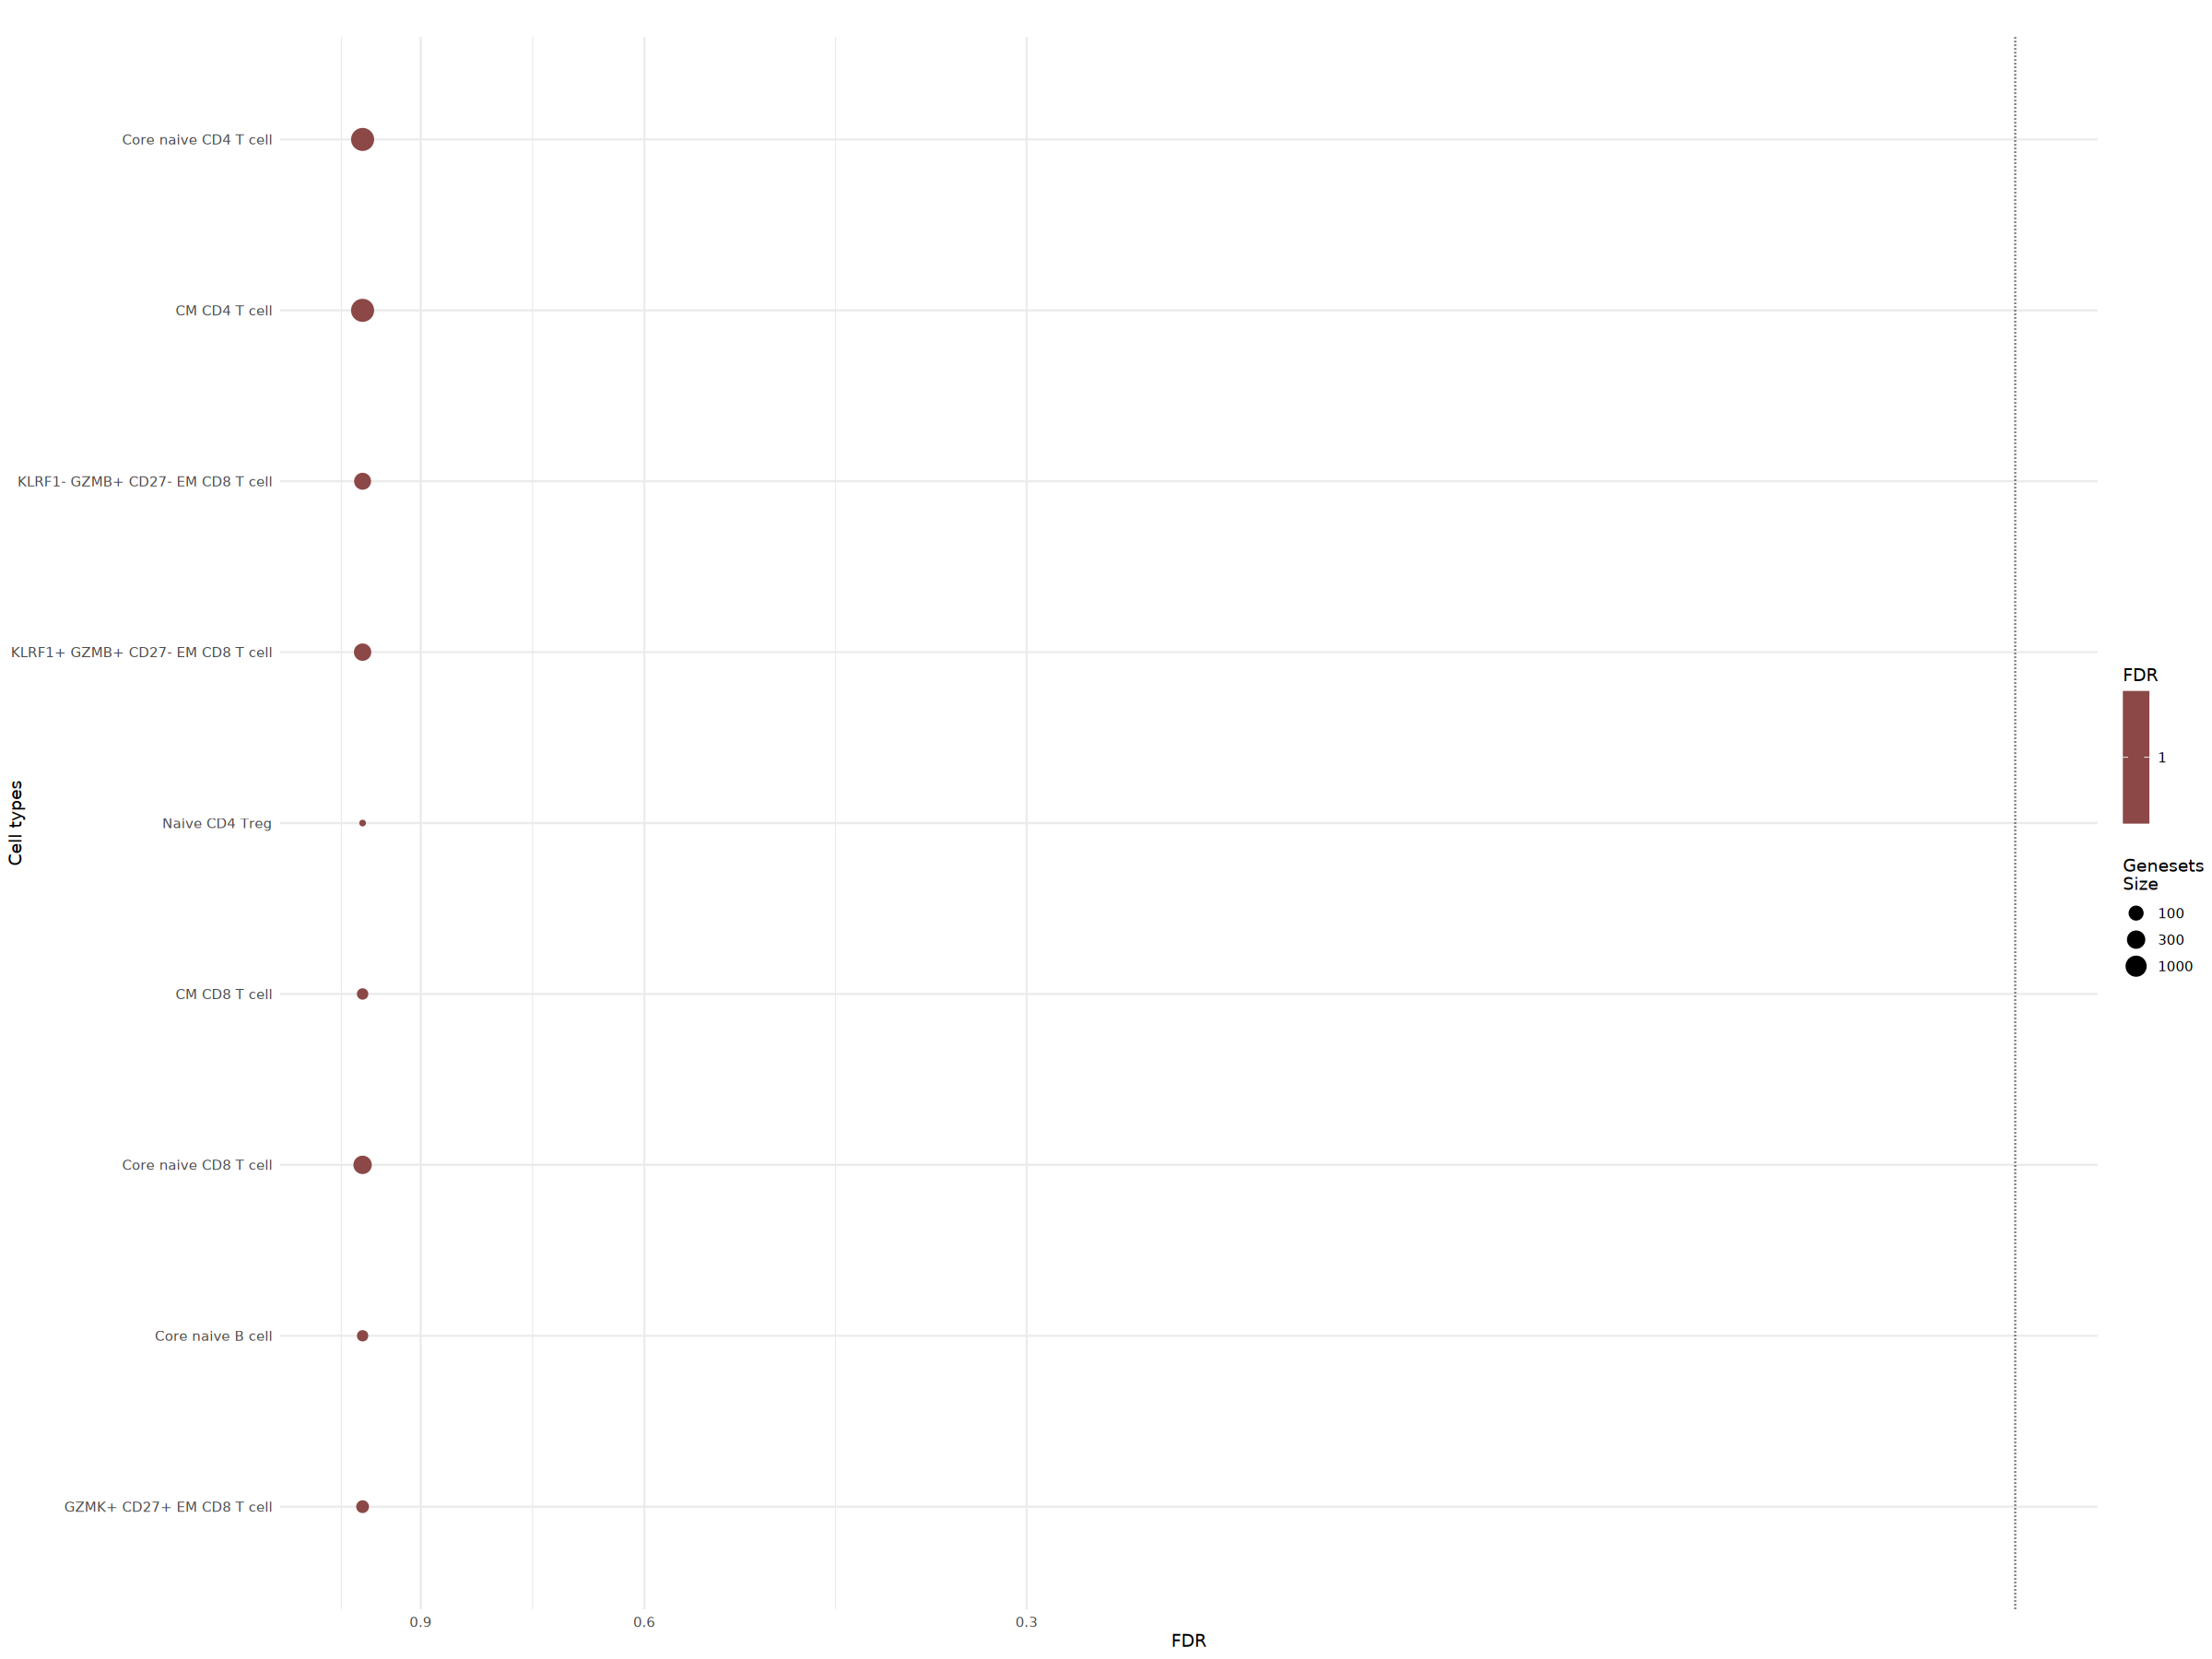

In [ ]:
p1 <- hyp_dots(hyp_obj) + theme_minimal() + xlab("Cell types")
p1
ggsave(file.path(fig_path, paste0(proj_name, "gene_signature_tnfi.pdf")), width = 6, height = 4)


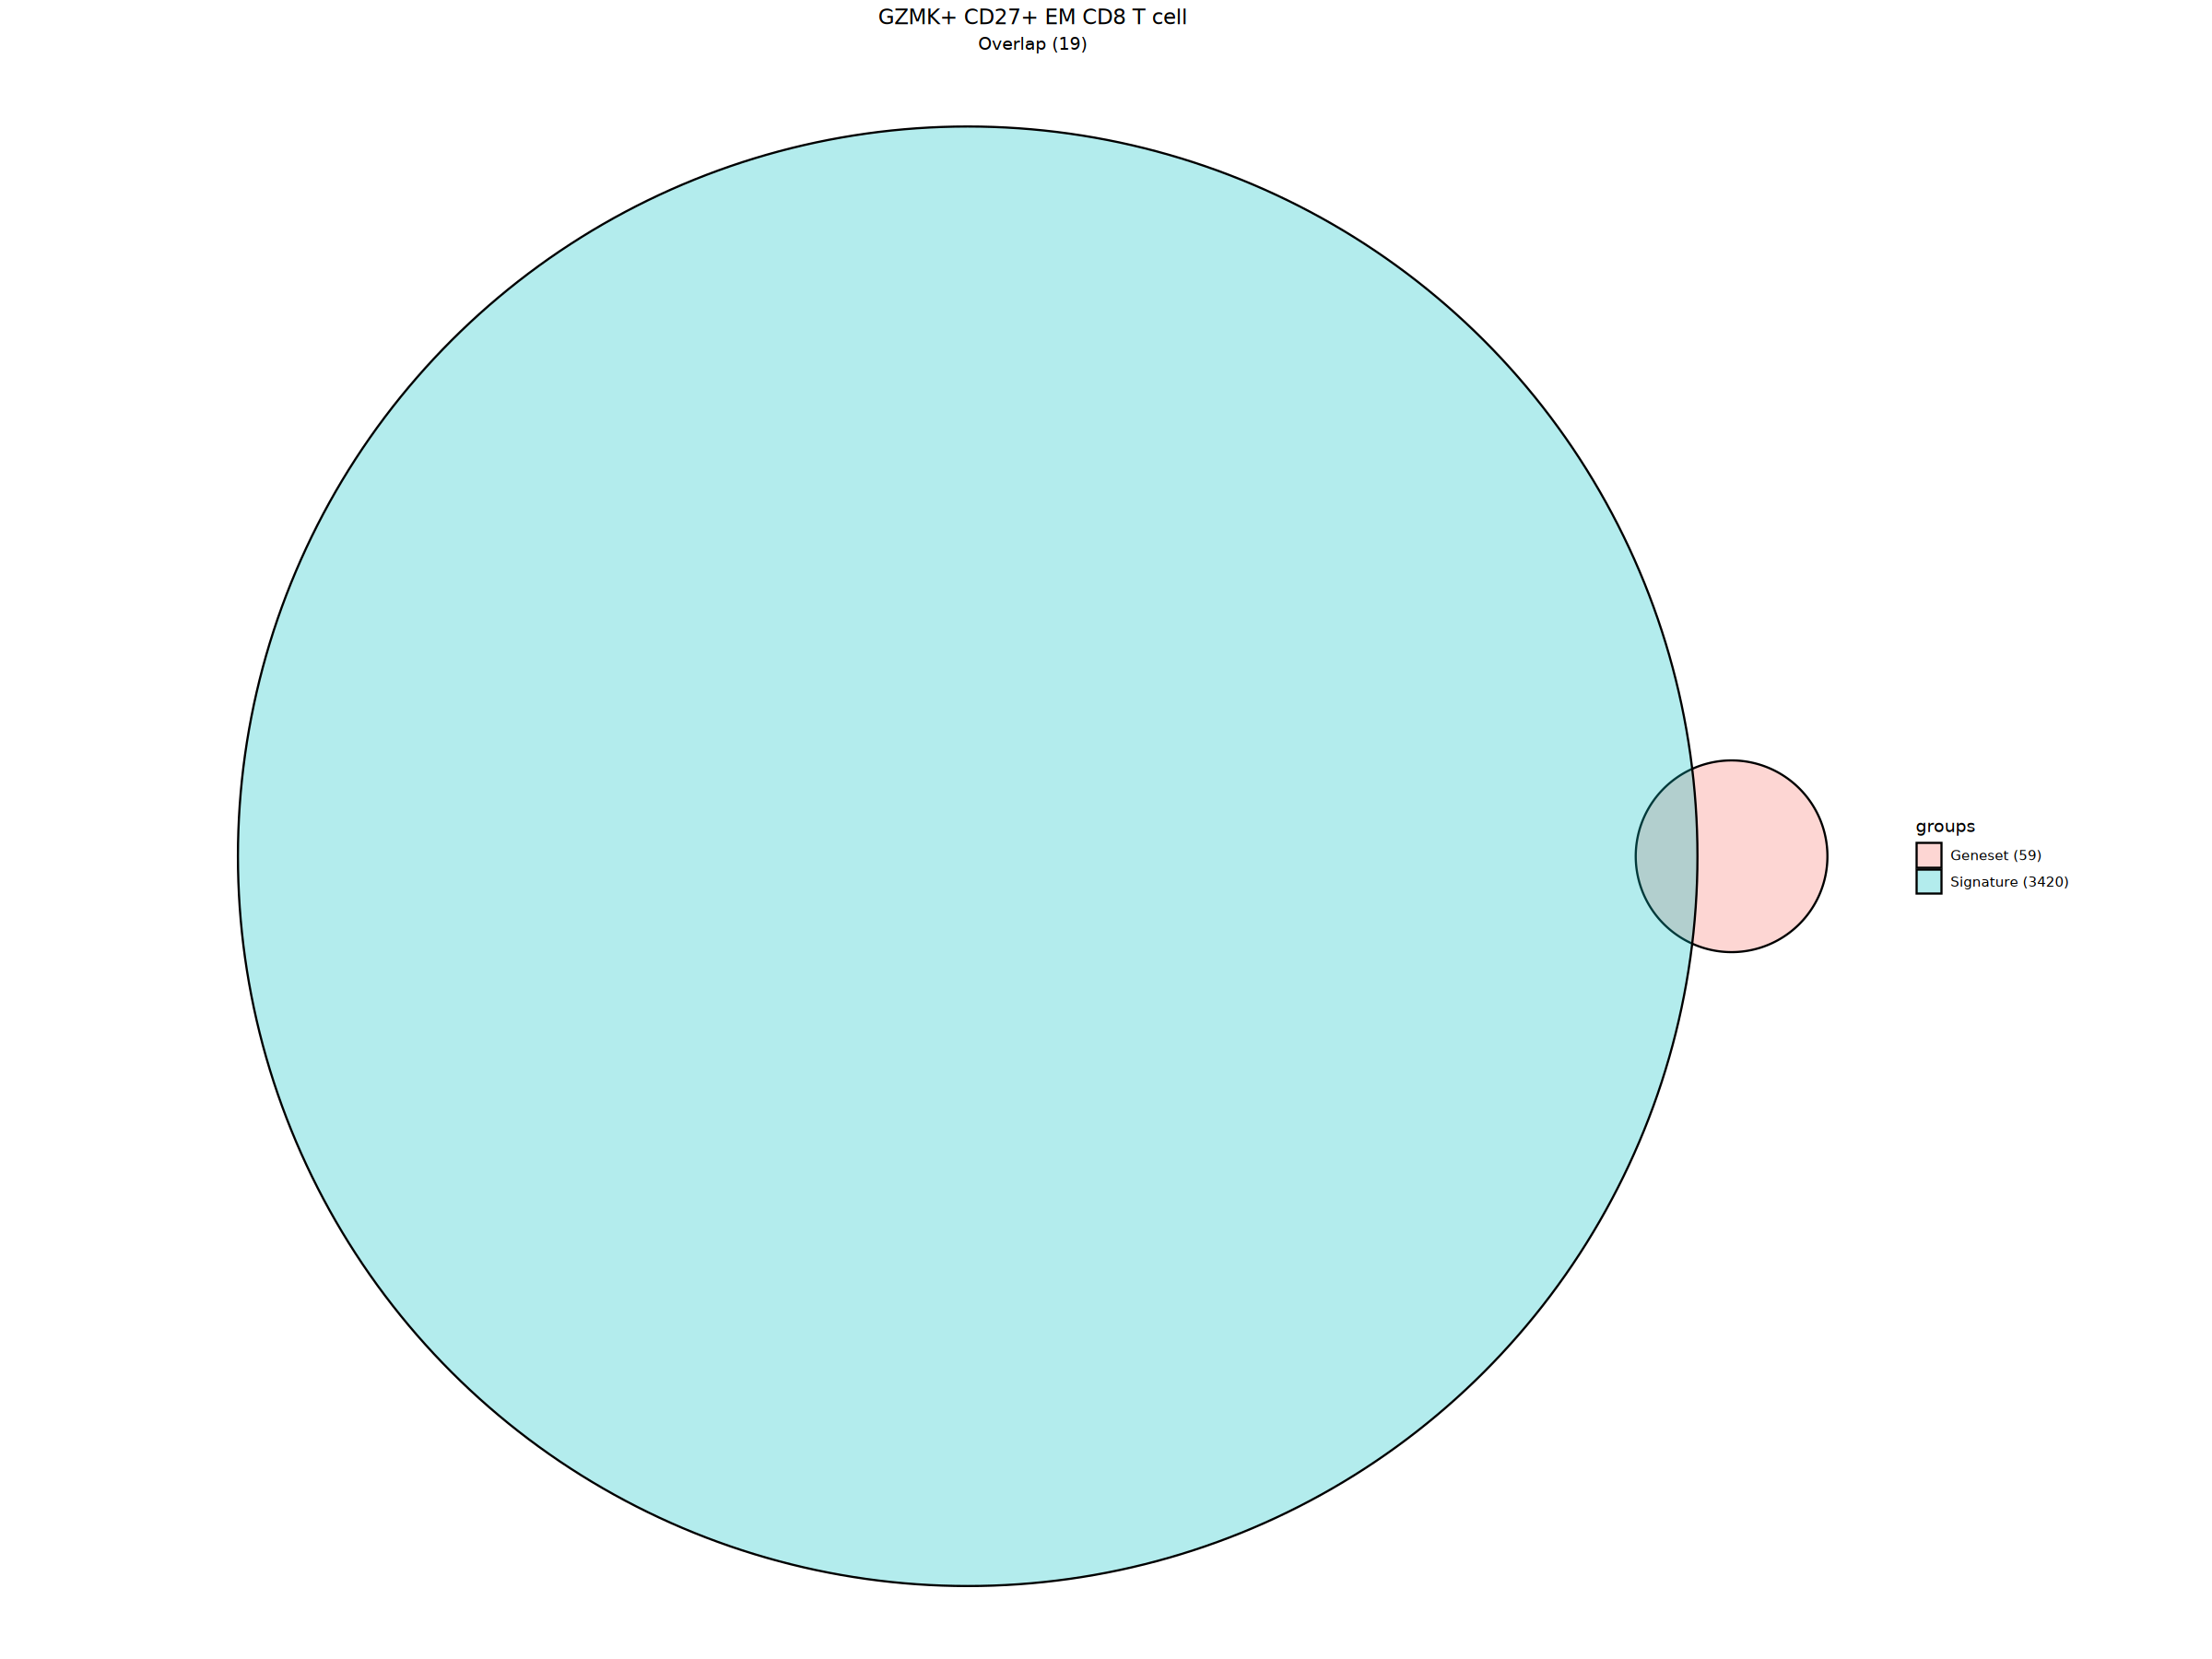

In [ ]:
hyp_obj$plots[[1]]


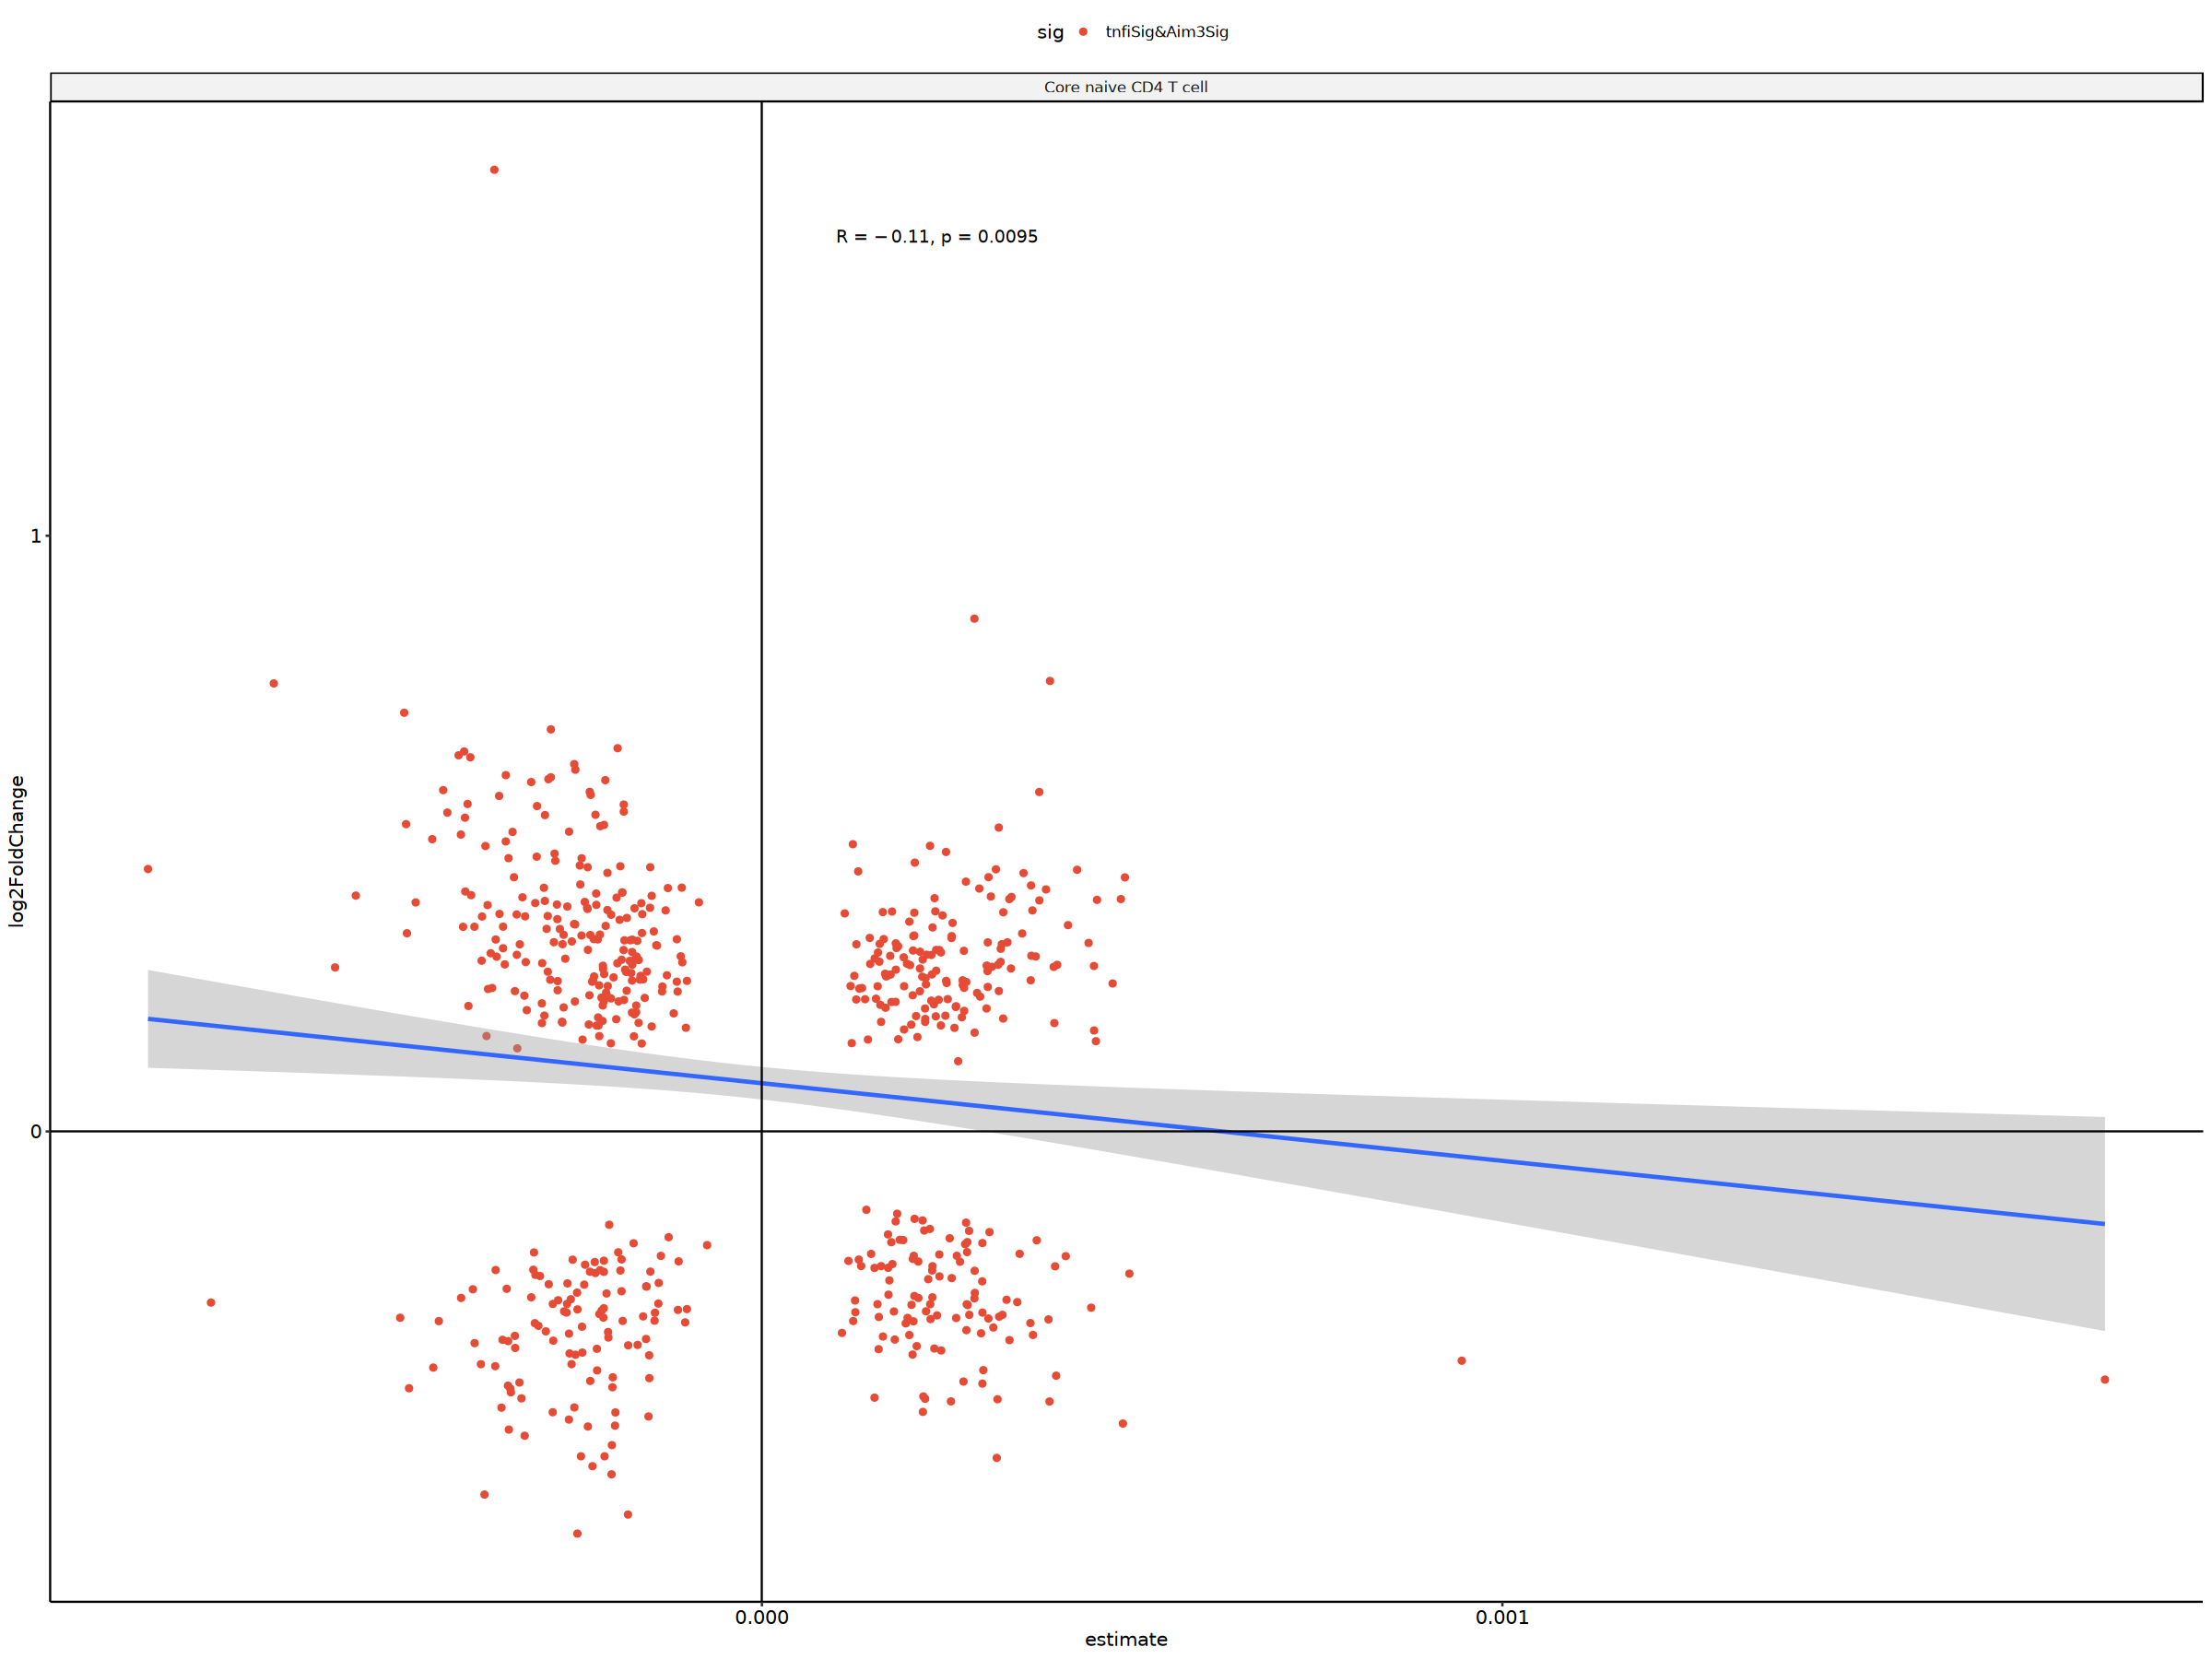

In [ ]:
# plot the significant genes
tnfi_aim3_degs_comparison %>%
    filter(q_values_tnfi < 0.1) %>%
    filter(cell_type %in% c("Core naive CD4 T cell")) %>%
    ggplot(aes(y = log2FoldChange, x = estimate)) +
    geom_point(aes(color = sig)) +
    # ggrepel::geom_text_repel(aes(label=gene),
    #                         ) +
    stat_smooth(
        method = "lm",
        formula = y ~ x,
        geom = "smooth"
    ) +
    geom_vline(xintercept = 0) +
    geom_hline(yintercept = 0) +
    ggpubr::stat_cor(method = "spearman", label.x = 0.0001, label.y = 1.5) +
    facet_wrap(vars(cell_type)) +
    scale_color_manual(values = npg_color) +
    theme_pubr()
ggsave(file.path(fig_path, paste0(proj_name, "_Aim3_deg_cd4na_logfc_cor_plot.png")),
    width = 4, height = 4
)


Warning message:
“ggrepel: 608 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 619 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


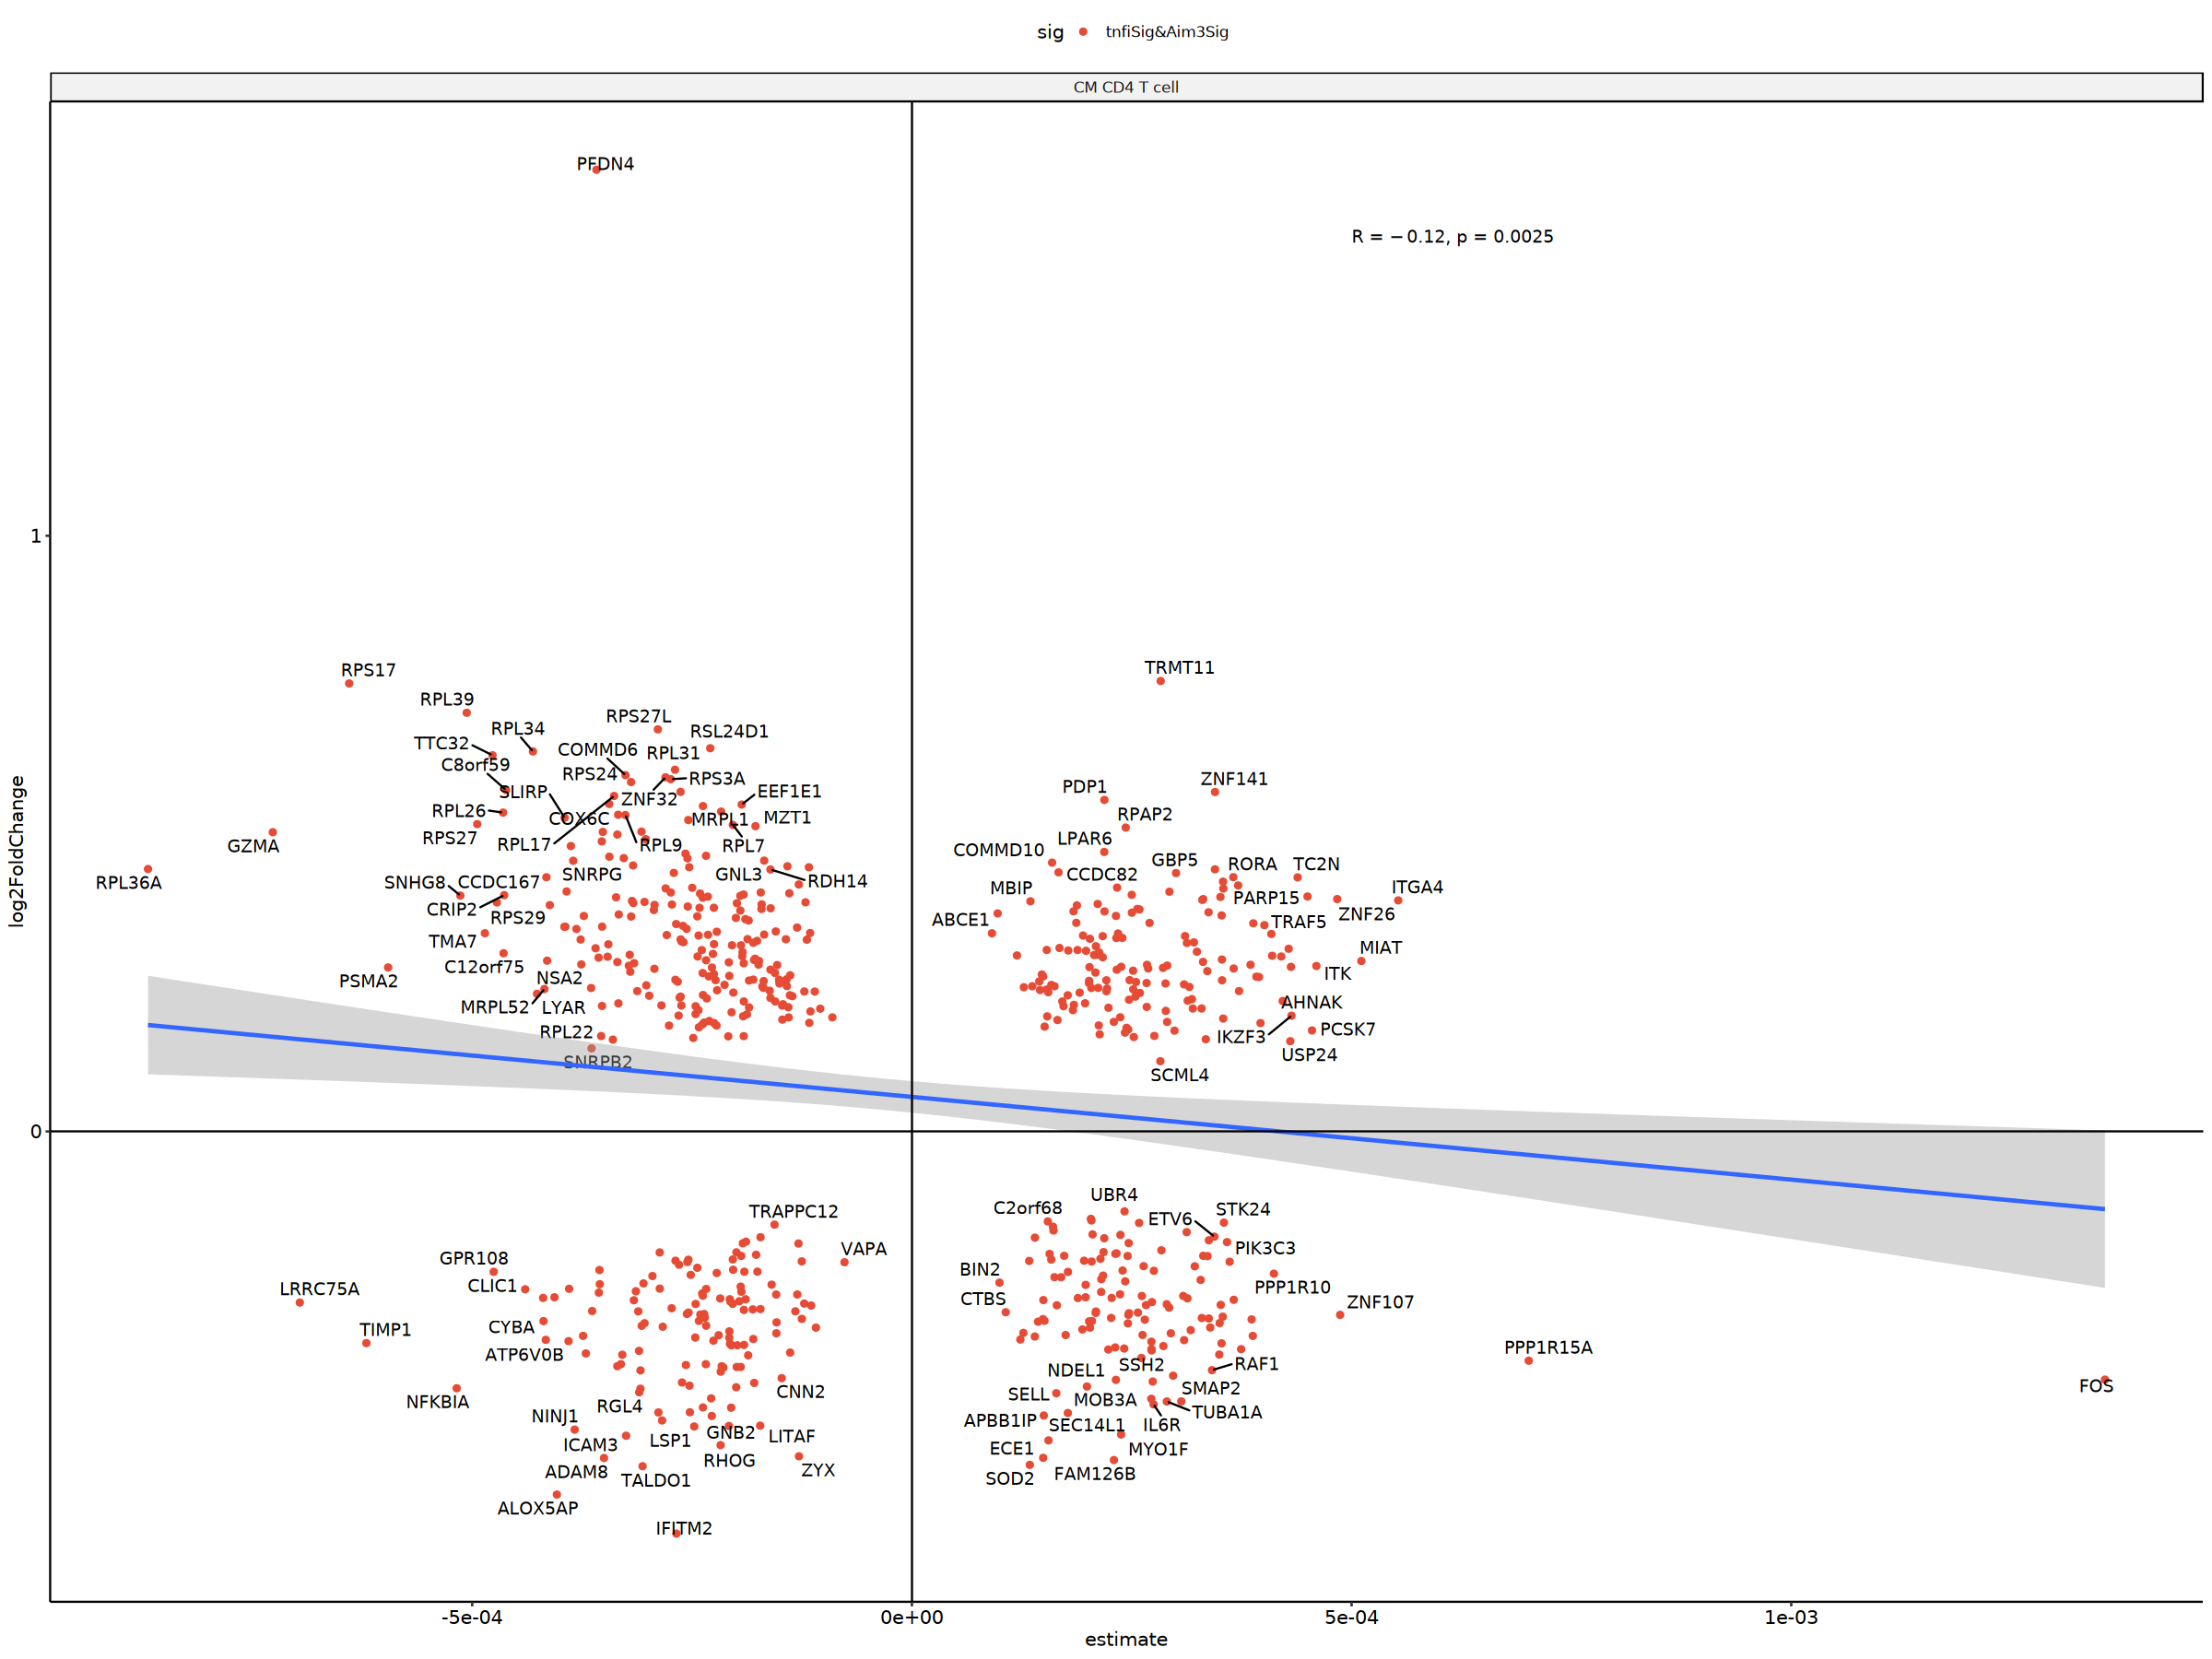

In [ ]:
# plot the significant genes
tnfi_aim3_degs_comparison %>%
    filter(cell_type %in% c("CM CD4 T cell")) %>%
    filter(q_values_tnfi < 0.1) %>%
    ggplot(aes(y = log2FoldChange, x = estimate)) +
    geom_point(aes(color = sig)) +
    ggrepel::geom_text_repel(aes(label = gene), ) +
    stat_smooth(
        method = "lm",
        formula = y ~ x,
        geom = "smooth"
    ) +
    geom_vline(xintercept = 0) +
    geom_hline(yintercept = 0) +
    ggpubr::stat_cor(method = "spearman", label.x = 0.0005, label.y = 1.5) +
    facet_wrap(vars(cell_type)) +
    scale_color_manual(values = npg_color) +
    theme_pubr()
ggsave(
    file.path(fig_path, paste0(
        proj_name,
        "Aim3_deg_cd4cm_logfc_cor_plot.png"
    )),
    width = 4, height = 4
)


### run mcnemar test


In [ ]:
# run mcnemar test
tnfi_aim3_degs_comparison_counts <- tnfi_aim3_degs_comparison %>%
    filter(q_values_tnfi < 0.1) %>%
    group_by(cell_type, aim3_direction, tnfi_direction) %>%
    tally() %>%
    ungroup()
celltypes_test <- tnfi_aim3_degs_comparison_counts %>%
    group_by(cell_type) %>%
    tally() %>%
    filter(n >= 4) %>%
    pull(cell_type)
celltypes_test

mcnemar_res <- tnfi_aim3_degs_comparison_counts %>%
    filter(cell_type %in% celltypes_test) %>%
    group_by(cell_type) %>%
    group_modify(~ run_mcnemar_test(.x))
# cont_counts = tnfi_aim3_degs_comparison_counts%>%filter(cell_type=='Core_naive_CD4_T_cell')%>%
#     pivot_wider(id_cols = aim3_direction, names_from = tnfi_direction , values_from = n)
# sex_counts = aim1_filedesc_fl%>%group_by(status, subject.biologicalSex)%>%tally()%>%
#     pivot_wider(id_cols = subject.biologicalSex, names_from = status , values_from = n)
# sex_counts
mcnemar_res


[1] "CM CD4 T cell"                    "Core naive CD4 T cell"           
[3] "Core naive CD8 T cell"            "GZMK+ CD27+ EM CD8 T cell"       
[5] "KLRF1+ GZMB+ CD27- EM CD8 T cell" "KLRF1- GZMB+ CD27- EM CD8 T cell"

cell_type,n,statistic,df,p,p.signif,method
<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CM CD4 T cell,622,25.760933,1,3.86e-07,****,McNemar test
Core naive CD4 T cell,580,32.078616,1,1.48e-08,****,McNemar test
Core naive CD8 T cell,76,32.326923,1,1.30e-08,****,McNemar test
GZMK+ CD27+ EM CD8 T cell,19,5.062500,1,2.44e-02,*,McNemar test
KLRF1+ GZMB+ CD27- EM CD8 T cell,42,7.259259,1,7.05e-03,**,McNemar test
KLRF1- GZMB+ CD27- EM CD8 T cell,36,8.450000,1,3.65e-03,**,McNemar test


In [ ]:
tnfi_aim3_degs_comparison_counts %>%
    filter(cell_type %in% c("CM CD4 T cell")) %>%
    pivot_wider(
        id_cols = c(cell_type, aim3_direction),
        names_from = tnfi_direction, values_from = n
    )


cell_type,aim3_direction,tnfi_down,tnfi_up
<chr>,<chr>,<int>,<int>
CM CD4 T cell,aim3_down,130,219
CM CD4 T cell,aim3_up,124,149


In [ ]:
# GGally::ggtable(tnfi_aim3_degs_comparison %>% filter(q_values_tnfi<0.1)%>%
#     filter(cell_type%in%c('Core_naive_CD4_T_cell', 'CM_CD4_T_cell')),
#         "cell_type", c("aim3_direction", "tnfi_direction"))


Warning message:
“ggrepel: 2549 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 47 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2497 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 191 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 272 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 162 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2549 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 48 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2497 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel:

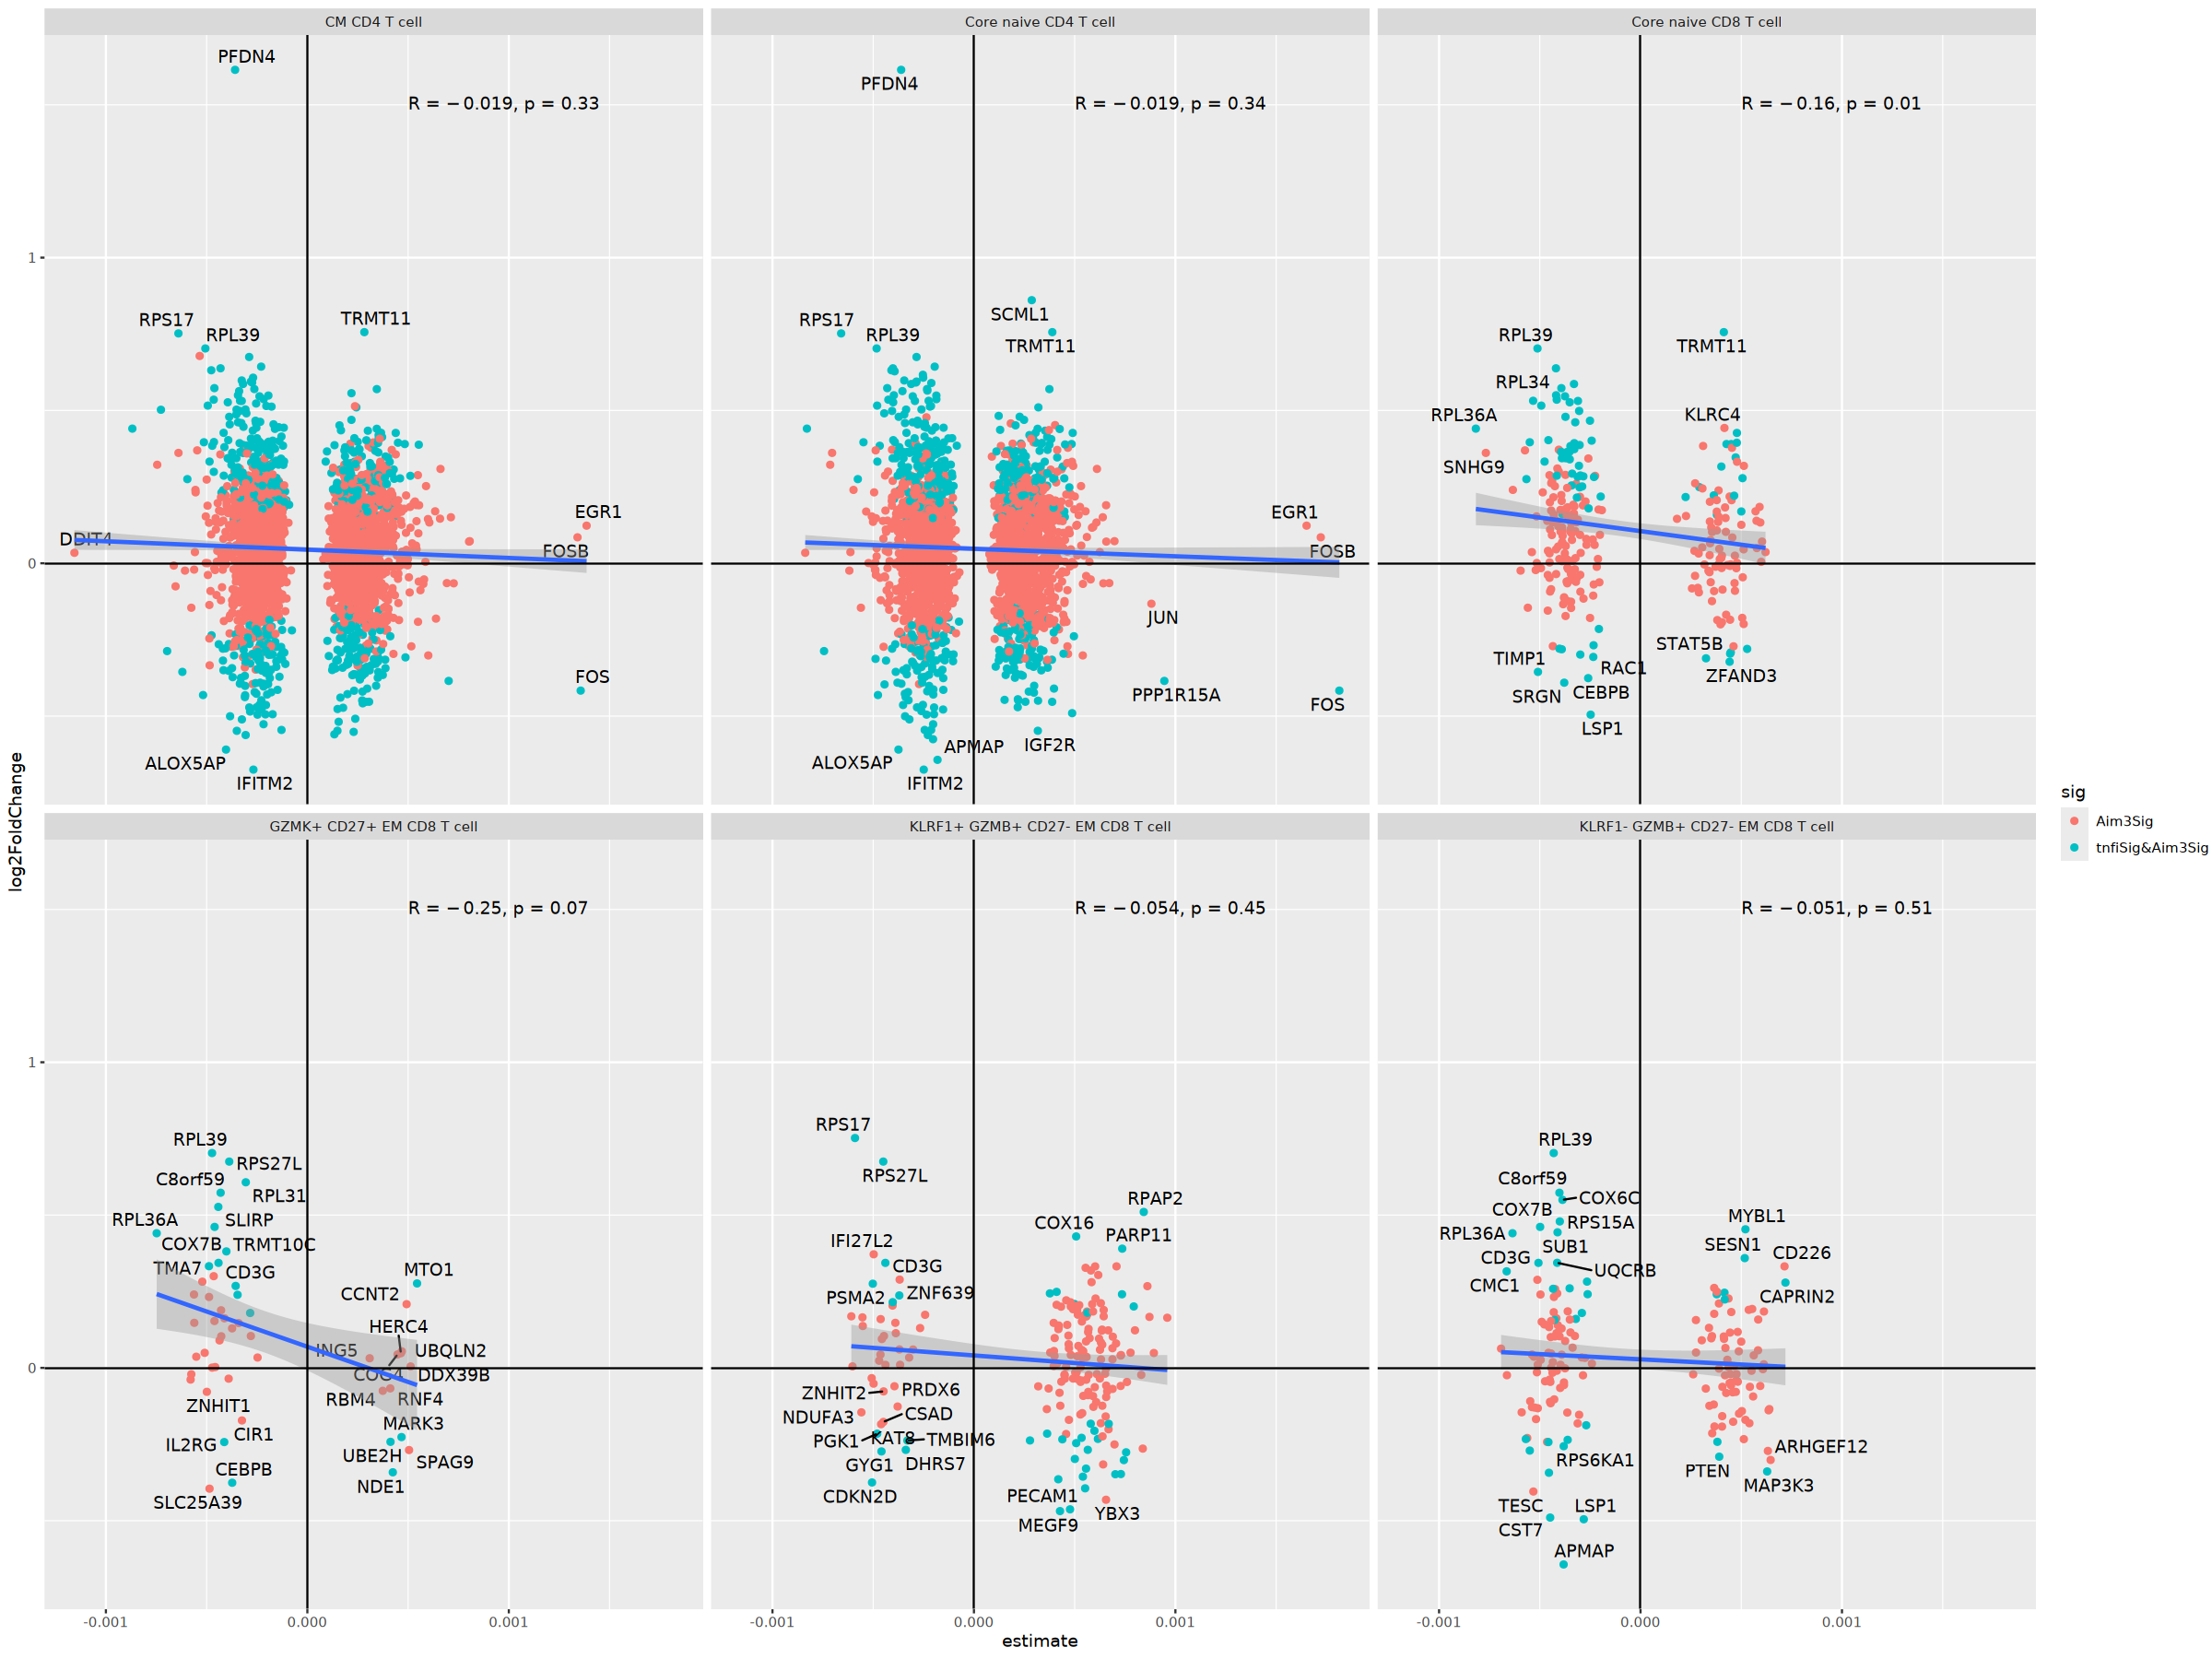

In [ ]:
tnfi_aim3_degs_comparison %>%
    filter(cell_type %in% celltypes_test) %>%
    ggplot(aes(y = log2FoldChange, x = estimate)) +
    geom_point(aes(color = sig)) +
    ggrepel::geom_text_repel(aes(label = gene)) +
    stat_smooth(
        method = "lm",
        formula = y ~ x,
        geom = "smooth"
    ) +
    geom_vline(xintercept = 0) +
    geom_hline(yintercept = 0) +
    ggpubr::stat_cor(method = "spearman", label.x = 0.0005, label.y = 1.5) +
    facet_wrap(vars(cell_type))
ggsave(file.path(fig_path, paste0("Aim3_deg_all_celltype_logfc_cor_plot.png")),
    width = 8, height = 6
)


In [ ]:
# tnfi_cor <- tnfi_aim3_degs_comparison %>% filter(!is.na(log2FoldChange) & !is.na(estimate))%>%
#   group_by(cell_type) %>%
#   rstatix::cor_test(log2FoldChange, estimate, method =  "spearman",
#                     conf.level=TRUE)


In [ ]:
# p1 <- ggplot(tnfi_cor, aes(x=cell_type, y=cor)) +
#   geom_segment( aes(x=cell_type, xend=cell_type, y=0, yend=cor), color="grey") +
#   geom_point( size=2) + #ylim(-0.5, 1)+
#   geom_hline(yintercept = 0 ,linetype=2)+
#  # geom_errorbar( aes( ymin=cor-sd, ymax=value+sd), width=0.4, colour="orange", alpha=0.9, size=1.3)+
#   theme_light() +  coord_flip()+
#   theme(
#     panel.grid.major.x = element_blank(),
#     panel.border = element_blank(),
#     axis.ticks.x = element_blank(),
#     #legend.position="none"
#   ) + scale_color_manual(values = npg_color)+
#   xlab("") +
#   ylab("spearman correlation coefficient") +
#     ggtitle('responder', )
# p1


# analyze non-responder


In [ ]:
# only keep paired analysis in responder
nonresp_paired_subj <- sample_metadata_fl %>%
    filter(eular_response == "None") %>%
    group_by(subject_id) %>%
    tally() %>%
    filter(n >= 2) %>%
    pull(subject_id)
nonresp_pair_metadata <- sample_metadata_fl %>% filter(subject_id %in% nonresp_paired_subj)
dds_nonresp <- dds[, colData(dds)$sample %in% nonresp_pair_metadata$sample]
dds_nonresp


class: DESeqDataSet 
dim: 25370 40 
metadata(1): version
assays(1): counts
rownames(25370): DDX11L1 WASH7P ... GOLGA2P3Y GOLGA2P2Y
rowData names(0):
colnames(40): C1-43-MO3 C1-76-BL ... C2-22-MO3 C2-124-BL
colData names(10): geo_id sample ... subject_id visit_time

In [ ]:
smallestGroupSize <- 20
keep <- rowSums(counts(dds_nonresp) >= 10) >= smallestGroupSize
dds_nonresp <- dds_nonresp[keep, ]
dds_nonresp


class: DESeqDataSet 
dim: 13502 40 
metadata(1): version
assays(1): counts
rownames(13502): WASH7P MIR6859-2 ... TMLHE CD24
rowData names(0):
colnames(40): C1-43-MO3 C1-76-BL ... C2-22-MO3 C2-124-BL
colData names(10): geo_id sample ... subject_id visit_time

In [ ]:
# set factor
dds_nonresp$visit_time <- factor(dds_nonresp$visit_time, levels = c("BASELINE", "MONTH 3"))
dds_nonresp$subject_id <- factor(dds_nonresp$subject_id)


In [ ]:
# run deseq2 in non-responder
dds_nonresp <- DESeq(dds_nonresp)
dds_nonresp_res <- results(dds_nonresp)
dds_nonresp_res_tb <- dds_nonresp_res %>% as_tibble(rownames = "gene")


estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [ ]:
# # calculate the qvalues
dds_nonresp_res_tb <- dds_nonresp_res_tb %>%
    mutate(q_values = qvalue::qvalue(pvalue)$qvalues) %>%
    select(-padj)
dds_nonresp_res_tb %>% head()


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
WASH7P,292.49611,-0.2137021,0.2508815,-0.8518049,0.39432237,0.9990215
MIR6859-2,89.97849,-0.1087481,0.1928132,-0.5640075,0.57274901,0.9990215
MIR6859-1,89.97849,-0.1087481,0.1928132,-0.5640075,0.57274901,0.9990215
LOC729737,4093.91255,-0.3296488,0.1731659,-1.9036594,0.05695456,0.9990215
LOC100132287,37.75727,-0.1340638,0.3846139,-0.3485672,0.72741422,0.9990215
LOC100133331,1053.71338,-0.2080051,0.2133473,-0.9749597,0.32958026,0.9990215


In [ ]:
# save the deg table
dds_nonresp_res_tb %>% write_csv(file.path(output_path, paste0(proj_name, "nonresponder_pre_post_degs.csv")))


In [ ]:
# load the deg table
dds_nonresp_res_tb <- read_csv(file.path(output_path, paste0(proj_name, "nonresponder_pre_post_degs.csv")))


Rows: 13502 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): gene
dbl (6): baseMean, log2FoldChange, lfcSE, stat, pvalue, q_values

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


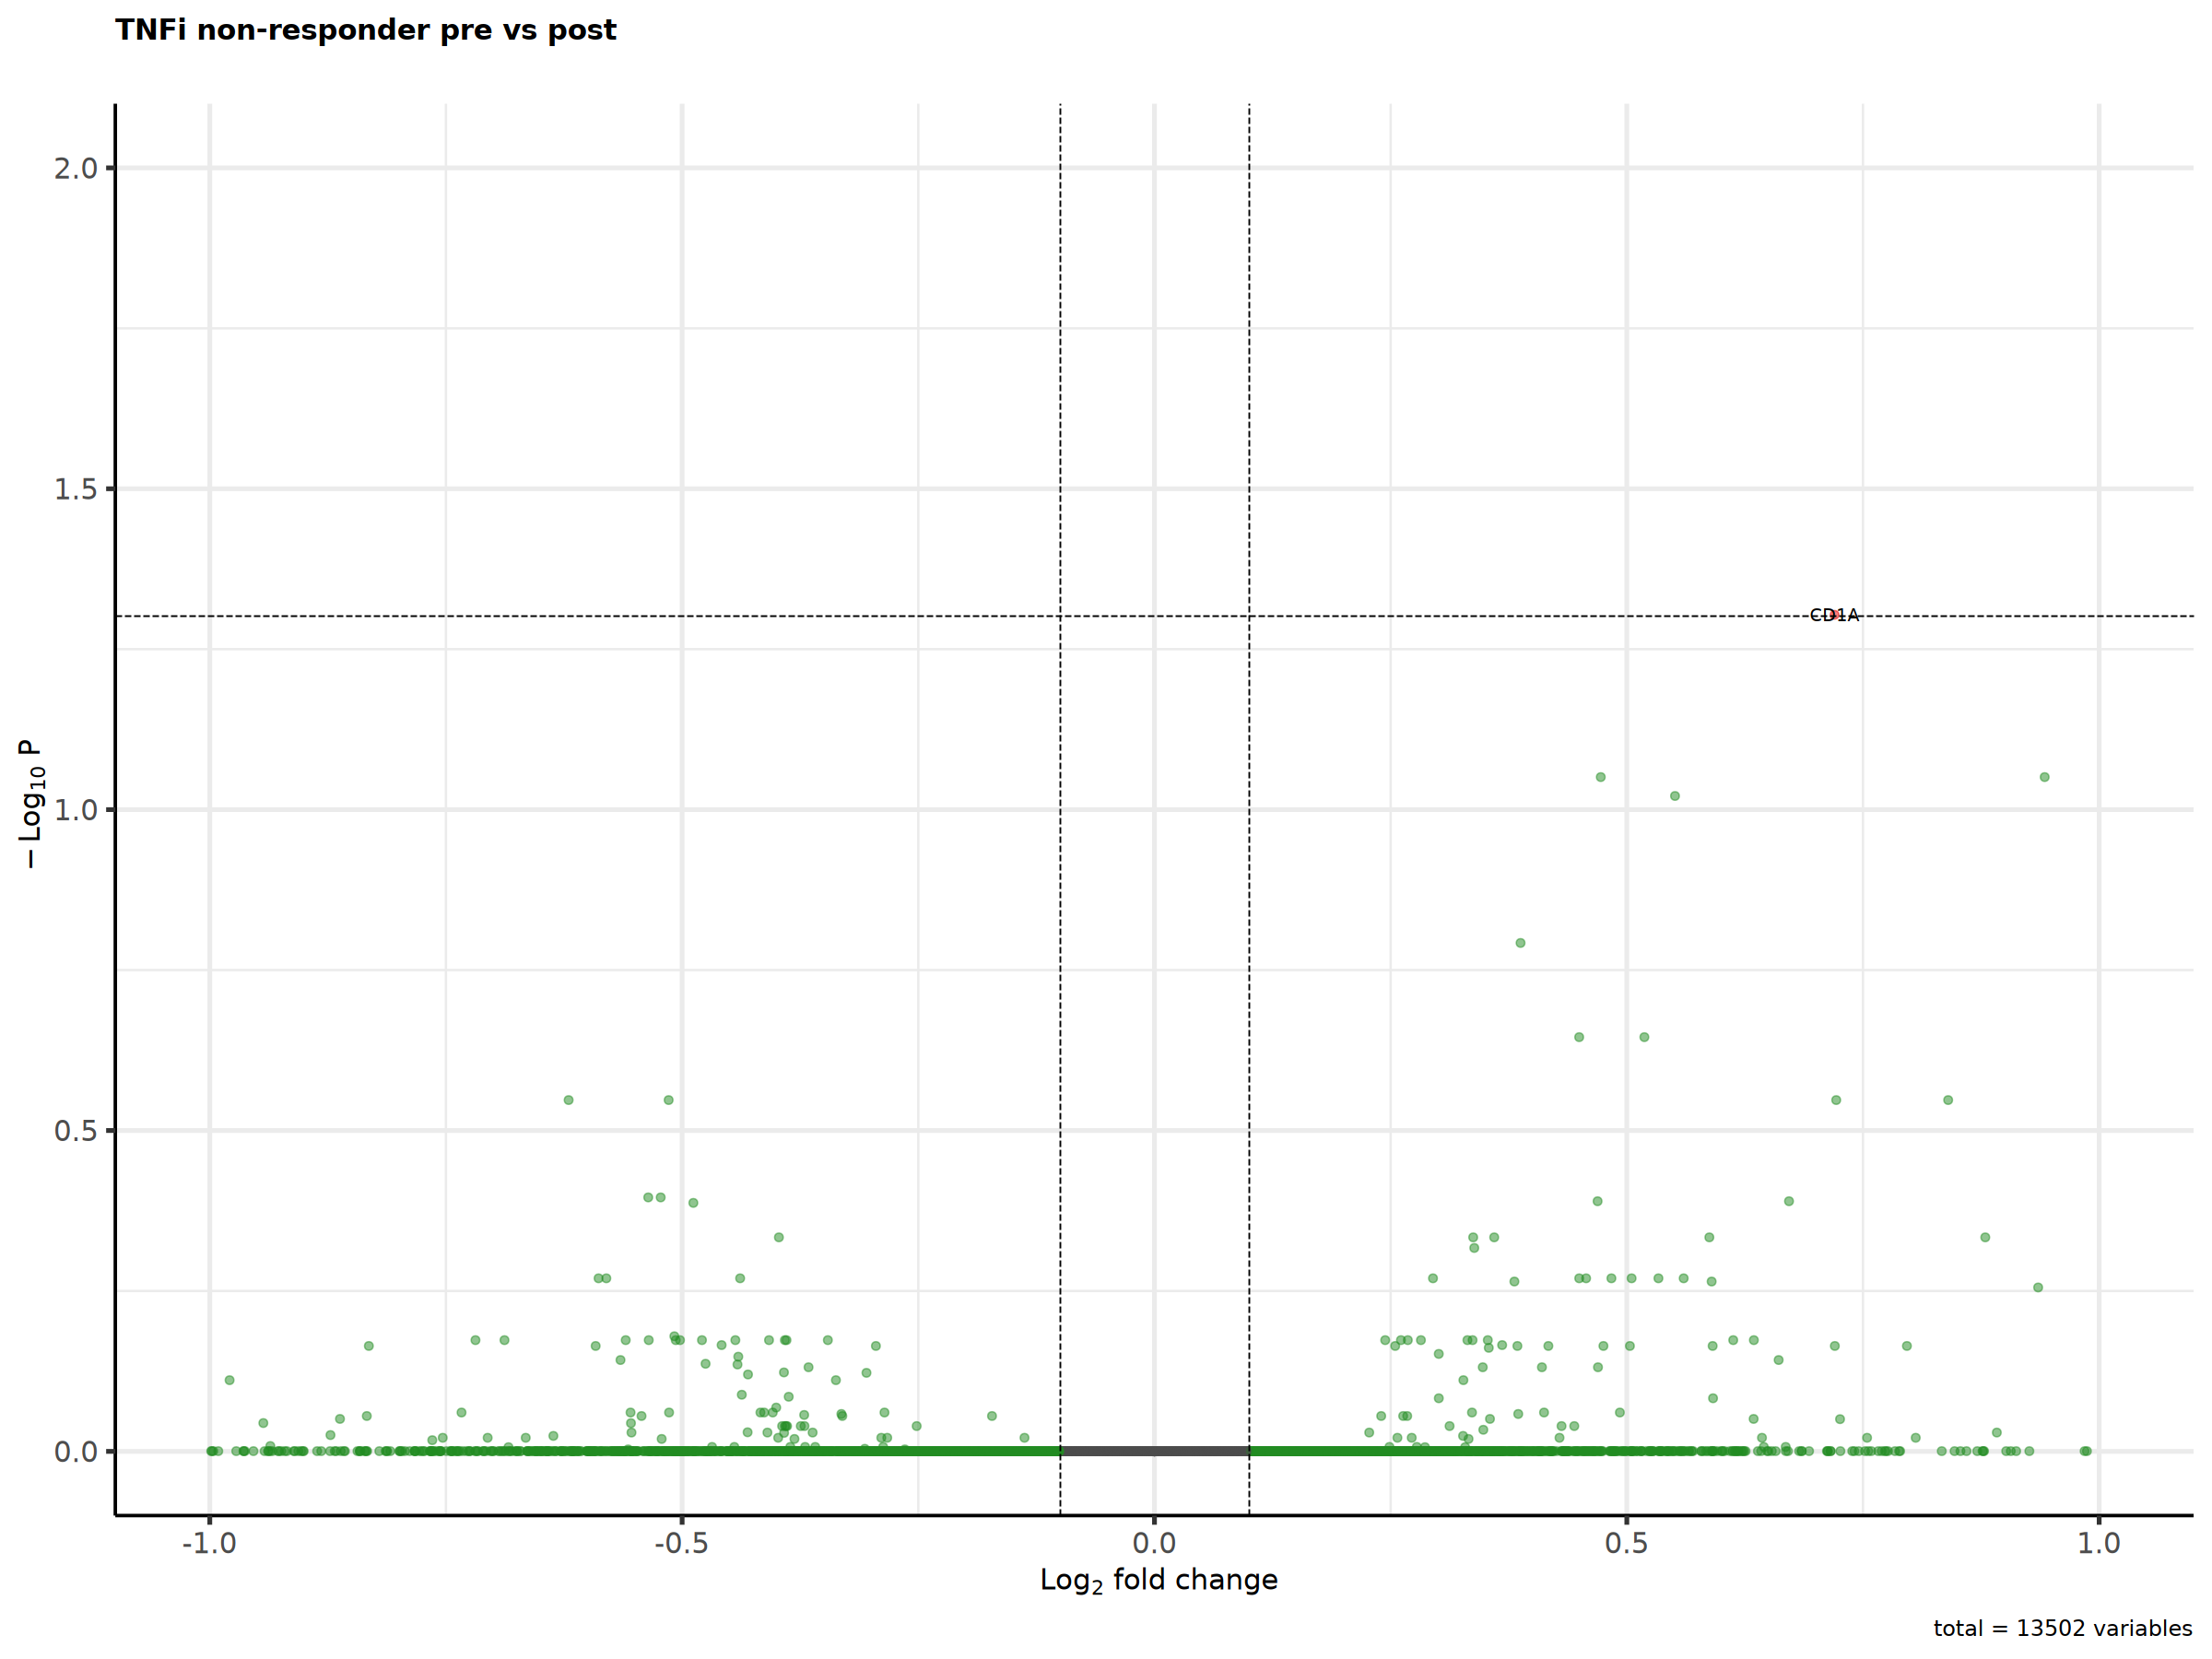

In [ ]:
# Plot the DA results for aim1
p1 <- EnhancedVolcano::EnhancedVolcano(dds_nonresp_res_tb,
    title = "TNFi non-responder pre vs post",
    subtitle = "",
    lab = dds_nonresp_res_tb$gene,
    x = "log2FoldChange",
    y = "q_values",
    pCutoff = 0.05,
    FCcutoff = 0.1,
    pointSize = 2.0, # drawConnectors = TRUE,
    widthConnectors = 1.0,
    colConnectors = "black", legendPosition = "none",
    arrowheads = FALSE,
    labSize = 4.0
) +
    xlim(c(-1, 1)) + ylim(0, 2)
p1
ggsave(file.path(fig_path, paste0(proj_name, "_nonresponders_prevspost_valcano_plot.png")),
    width = 8, height = 6
)


### run a HyperGeometric Enrichment test


In [ ]:
library(hypeR)


In [ ]:
# # use tnfi response genes as the reference
# # check if the aim3 degs are significant enriched.
# celltype_test = 'Core_naive_CD4_T_cell'
# aim3_sig_genes <- aim3_degs %>%
#     filter(cell_type==celltype_test&q_values<0.1)%>%pull(gene)
# aim3_bg_genes <- aim3_degs %>%
#     filter(cell_type==celltype_test)%>%pull(gene)

# tnfi_sig_genes <- dds_nonresp_res_tb%>%filter(q_values<0.1)%>%pull(gene)
# hyp_obj <- hypeR(aim3_sig_genes, tnfi_genes_list,
#                  test="hypergeometric", background=length(aim3_bg_genes), plotting=TRUE)
# hyp_obj


In [ ]:
# make a degs list per cell type
celltypes_test <- aim3_degs %>%
    filter(q_values < 0.1) %>%
    group_by(cell_type) %>%
    tally() %>%
    filter(n > 10) %>%
    pull(cell_type) %>%
    unique()
aim3_genes_list <- lapply(celltypes_test, function(x) {
    sig_genes <- aim3_degs %>%
        filter(cell_type == x & q_values < 0.1) %>%
        pull(gene)
    return(sig_genes)
})
names(aim3_genes_list) <- celltypes_test
celltypes_test


[1] "CM CD4 T cell"                    "CM CD8 T cell"                   
[3] "Core naive B cell"                "Core naive CD4 T cell"           
[5] "Core naive CD8 T cell"            "GZMK+ CD27+ EM CD8 T cell"       
[7] "KLRF1+ GZMB+ CD27- EM CD8 T cell" "KLRF1- GZMB+ CD27- EM CD8 T cell"
[9] "Naive CD4 Treg"

In [ ]:
dds_nonresp_res_tb %>%
    filter(q_values < 0.1) %>%
    pull(gene)


[1] "FCRL5"    "CD1A"     "G0S2"     "POU2AF1"  "TNFRSF17" "IGJ"      "MZB1"

In [ ]:
# aim3_genes_list
tnfinon_sig_genes <- dds_nonresp_res_tb %>%
    filter(q_values < 0.1) %>%
    pull(gene)
tnfinon_bg_genes <- dds_nonresp_res_tb %>% pull(gene)

hyp_nonp <- hypeR(tnfinon_sig_genes, aim3_genes_list,
    test = "hypergeometric", background = length(tnfinon_bg_genes), plotting = TRUE
)


Warning message in .check_overlap(signature, gsets.obj$genesets):
“Only 0% of signature was found across genesets”


In [ ]:
hyp_to_excel(hyp_nonp, file_path = file.path(output_path, "non_responders_pathways.xlsx"))


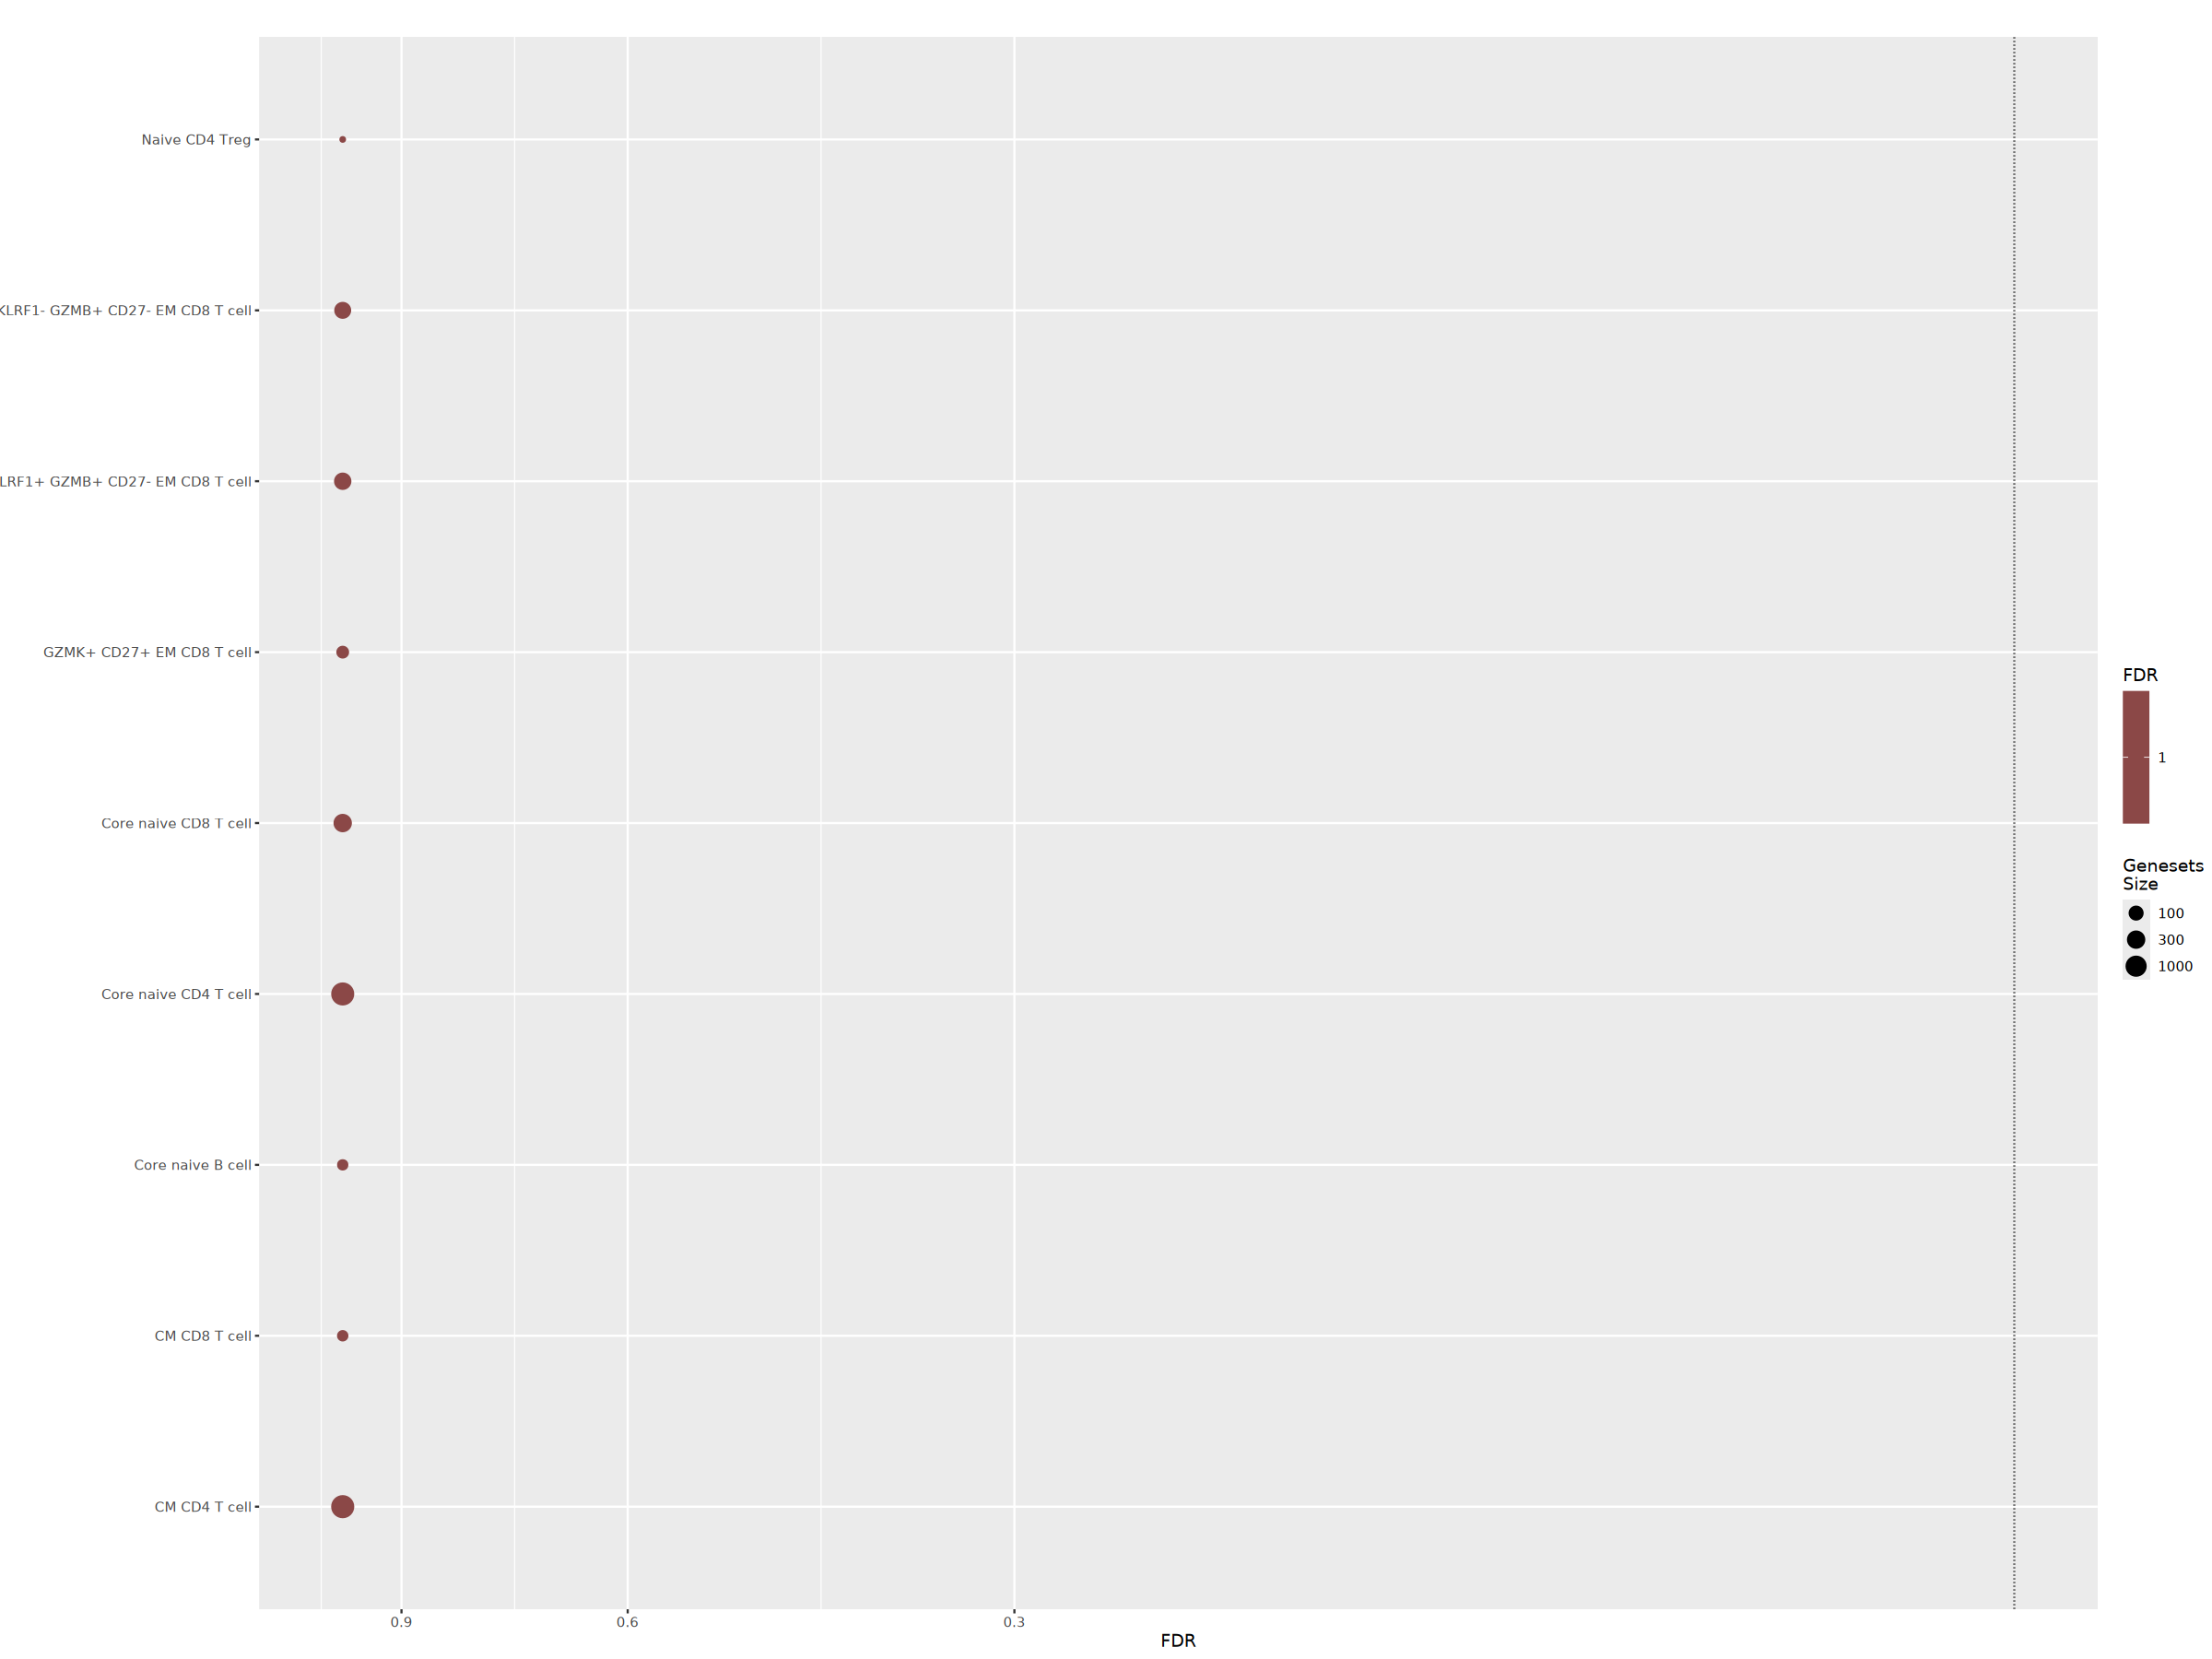

In [ ]:
hyp_dots(hyp_nonp)
ggsave(file.path(fig_path, paste0(proj_name, "gene_signature_nonresponder.png")), width = 8, height = 4)


In [ ]:
# combine the deg results
tnfinon_aim3_degs_comparison <- dds_nonresp_res_tb %>%
      full_join(aim3_degs,
            by = c("gene"),
            suffix = c("_tnfi", "_aim3")
      ) %>%
      dplyr::rename("pvalue_aim3" = "p.value") %>%
      filter(q_values_aim3 < 0.1 & q_values_tnfi < 0.1 &
            !is.na(log2FoldChange)) %>%
      mutate(sig = case_when(
            q_values_tnfi <= 0.05 & q_values_aim3 <= 0.1 ~ "tnfiSig&Aim3Sig",
            q_values_tnfi > 0.05 & q_values_aim3 <= 0.1 ~ "Aim3Sig",
            q_values_tnfi <= 0.05 & q_values_aim3 > 0.1 ~ "tnfiSig",
            q_values_tnfi > 0.05 & q_values_aim3 > 0.1 ~ "No sig"
      )) %>%
      mutate(
            aim3_direction = if_else(estimate > 0, "aim3_up", "aim3_down"),
            tnfi_direction = if_else(log2FoldChange > 0, "tnfi_up", "tnfi_down")
      )
tnfinon_aim3_degs_comparison %>% colnames()


[1] "gene"           "baseMean"       "log2FoldChange" "lfcSE"         
 [5] "stat"           "pvalue"         "q_values_tnfi"  "cell_type"     
 [9] "effect"         "group"          "term"           "estimate"      
[13] "std.error"      "statistic"      "df"             "pvalue_aim3"   
[17] "q_values_aim3"  "sig"            "aim3_direction" "tnfi_direction"

In [ ]:
tnfinon_aim3_degs_comparison %>% filter(is.na(sig))


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values_tnfi,cell_type,effect,group,term,estimate,std.error,statistic,df,pvalue_aim3,q_values_aim3,sig,aim3_direction,tnfi_direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>


In [ ]:
# calculate the numbers
tnfinon_aim3_degs_comparison_counts <- tnfinon_aim3_degs_comparison %>%
    group_by(cell_type, aim3_direction, tnfi_direction) %>%
    tally() %>%
    ungroup()
tnfinon_aim3_degs_comparison_counts


cell_type,aim3_direction,tnfi_direction,n
<chr>,<chr>,<chr>,<int>


In [ ]:
tnfinon_aim3_degs_comparison_counts %>%
    filter(cell_type %in% c("CM CD4 T cell")) %>%
    pivot_wider(
        id_cols = c(cell_type, aim3_direction),
        names_from = tnfi_direction, values_from = n
    )


cell_type,aim3_direction
<chr>,<chr>


In [ ]:
tnfinon_aim3_degs_comparison_counts %>% head()


cell_type,aim3_direction,tnfi_direction,n
<chr>,<chr>,<chr>,<int>


# plot the gene set enrichment results for responders and non-responders


In [ ]:
# combine the HyperGeometric test result
resp_data <- hyp_obj$data %>%
    as_tibble(rownames = "cell_type") %>%
    mutate(response = "Responder")
nonp_data <- hyp_nonp$data %>%
    as_tibble(rownames = "cell_type") %>%
    mutate(response = "Non-responder")
hyp_results <- resp_data %>%
    bind_rows(nonp_data) %>%
    mutate(
        cell_type = factor(cell_type, levels = rev(unique(cell_type))),
        "log10_FDR" = -log10(fdr), "log10_NomP" = -log10(pval),
        cell_type_anno = recode(cell_type,
            "Core naive CD4 T cell" = "Naive CD4 T",
            "CM CD4 T cell" = "CM CD4 T",
            "Core naive CD8 T cell" = "Naive CD8 T",
            "KLRF1+ GZMB+ CD27- EM CD8 T cell" = "KLRF1+ CD8 EM",
            "Core naive B cell" = "Core naive B",
            "KLRF1- GZMB+ CD27- EM CD8 T cell" = "KLRF1- CD8 EM",
            "GZMK+ CD27+ EM CD8 T cell" = "GZMK+ CD8 EM"
        )
    )
hyp_results %>% select(-hits)


cell_type,label,pval,fdr,signature,geneset,overlap,background,response,log10_FDR,log10_NomP,cell_type_anno
<fct>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<fct>
GZMK+ CD27+ EM CD8 T cell,GZMK+ CD27+ EM CD8 T cell,0.14,1,3420,59,19,13507,Responder,0,0.85387196,GZMK+ CD8 EM
Core naive B cell,Core naive B cell,0.47,1,3420,45,12,13507,Responder,0,0.32790214,Core naive B
Core naive CD8 T cell,Core naive CD8 T cell,0.59,1,3420,305,76,13507,Responder,0,0.22914799,Naive CD8 T
CM CD8 T cell,CM CD8 T cell,0.64,1,3420,46,11,13507,Responder,0,0.19382003,CM CD8 T cell
Naive CD4 Treg,Naive CD4 Treg,0.74,1,3420,32,7,13507,Responder,0,0.13076828,Naive CD4 Treg
KLRF1+ GZMB+ CD27- EM CD8 T cell,KLRF1+ GZMB+ CD27- EM CD8 T cell,0.97,1,3420,209,42,13507,Responder,0,0.01322827,KLRF1+ CD8 EM
KLRF1- GZMB+ CD27- EM CD8 T cell,KLRF1- GZMB+ CD27- EM CD8 T cell,0.97,1,3420,181,36,13507,Responder,0,0.01322827,KLRF1- CD8 EM
CM CD4 T cell,CM CD4 T cell,1.00,1,3420,2712,622,13507,Responder,0,0.00000000,CM CD4 T
Core naive CD4 T cell,Core naive CD4 T cell,1.00,1,3420,2651,580,13507,Responder,0,0.00000000,Naive CD4 T


In [ ]:
output_path


[1] "/home/workspace/private/ra-cohort-ide/ALTRA_revision/TNFi/GSE129705/results"

In [ ]:
hyp_results %>% write_csv(file.path(output_path, paste0(proj_name, "_geneset_enrichment_results.csv")))


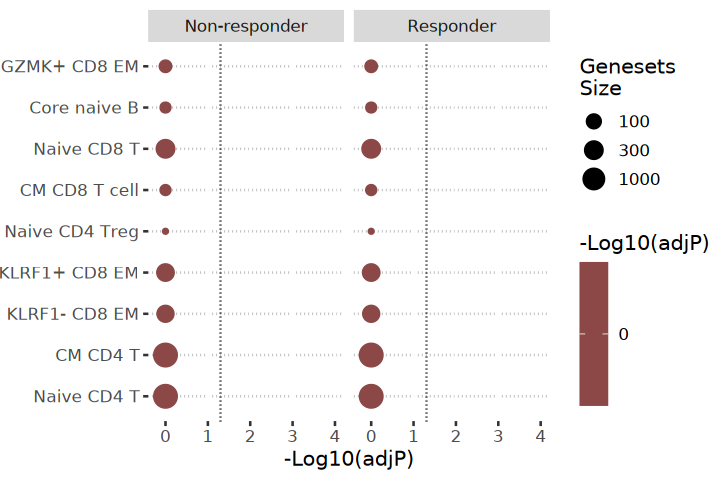

In [ ]:
# plot the pathway enrichment results
options(repr.plot.width = 6, repr.plot.height = 4)
p1 <- ggplot(hyp_results, aes(
      x = log10_FDR, size = geneset,
      y = cell_type_anno,
      color = log10_FDR
)) +
      geom_point() +
      facet_wrap(vars(response)) +
      scale_color_continuous(low = "#114357", high = "#E53935") +
      geom_vline(xintercept = -log10(0.05), linetype = "dotted") +
      ggpubr::theme_pubclean() +
      xlim(c(-0.2, 4)) +
      theme(
            axis.text.y = element_text(size = 10),
            axis.title.y = element_blank(), legend.position = "right"
      ) +
      scale_size_continuous(trans = scales::log10_trans()) +
      labs(size = "Genesets\nSize", x = "-Log10(adjP)", color = "-Log10(adjP)")
p1
ggsave(file.path(fig_path, paste0(proj_name, "_geneset_enrichment_fdr.pdf")),
      width = 6, height = 4
)


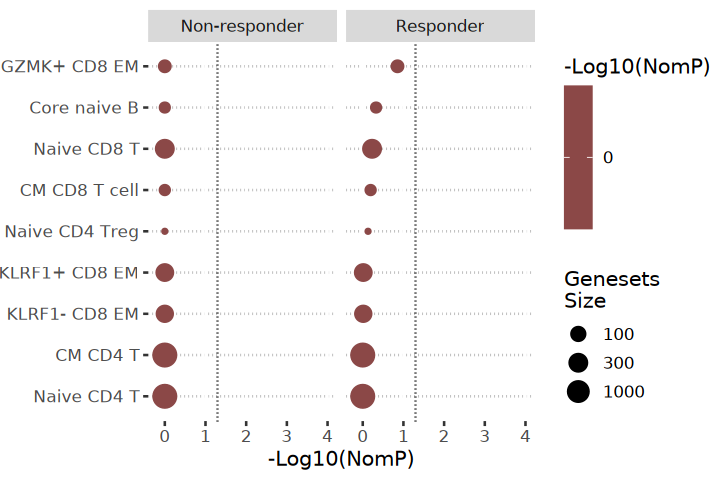

In [ ]:
# plot the pathway enrichment results
options(repr.plot.width = 6, repr.plot.height = 4)
p1 <- ggplot(hyp_results, aes(
      x = log10_NomP, size = geneset,
      y = cell_type_anno,
      color = log10_FDR
)) +
      geom_point() +
      facet_wrap(vars(response)) +
      scale_color_continuous(low = "#114357", high = "#E53935") +
      geom_vline(xintercept = -log10(0.05), linetype = "dotted") +
      ggpubr::theme_pubclean() +
      xlim(c(-0.2, 4)) +
      theme(
            axis.text.y = element_text(size = 10),
            axis.title.y = element_blank(), legend.position = "right"
      ) +
      scale_size_continuous(trans = scales::log10_trans()) +
      labs(size = "Genesets\nSize", x = "-Log10(NomP)", color = "-Log10(NomP)")
p1
ggsave(file.path(fig_path, paste0(proj_name, "_geneset_enrichment_nomp.png")),
      width = 6, height = 4
)


In [ ]:
tnfi_aim3_degs_comparison


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values_tnfi,cell_type,effect,group,term,estimate,std.error,statistic,df,pvalue_aim3,q_values_aim3,sig,aim3_direction,tnfi_direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
NOC2L,764.93406,0.051938451,0.11438922,0.45405024,0.649792666,0.42658815,CM CD4 T cell,fixed,NA,days_to_conversion,0.0001235382,7.985345e-05,1.547061,46.00000,0.1287014682,0.09362618,Aim3Sig,aim3_up,tnfi_up
ISG15,4638.73375,0.177832795,0.28138085,0.63200034,0.527386654,0.38424630,CM CD4 T cell,fixed,NA,days_to_conversion,-0.0003363031,1.260527e-04,-2.667956,37.81073,0.0111746436,0.04306205,Aim3Sig,aim3_down,tnfi_up
ISG15,4638.73375,0.177832795,0.28138085,0.63200034,0.527386654,0.38424630,Core naive CD4 T cell,fixed,NA,days_to_conversion,-0.0003561665,1.177210e-04,-3.025513,37.32288,0.0044766934,0.03191558,Aim3Sig,aim3_down,tnfi_up
ISG15,4638.73375,0.177832795,0.28138085,0.63200034,0.527386654,0.38424630,Core naive CD8 T cell,fixed,NA,days_to_conversion,-0.0003710419,1.131100e-04,-3.280362,37.84117,0.0022314775,0.07112603,Aim3Sig,aim3_down,tnfi_up
UBE2J2,1325.91956,-0.173802471,0.10559037,-1.64600690,0.099762339,0.15168250,Core naive CD4 T cell,fixed,NA,days_to_conversion,-0.0001996799,1.234979e-04,-1.616868,45.92149,0.1127565654,0.08265596,Aim3Sig,aim3_down,tnfi_down
AURKAIP1,1150.37259,-0.241235116,0.15440563,-1.56234660,0.118206360,0.16650987,CM CD4 T cell,fixed,NA,days_to_conversion,-0.0002864344,1.272799e-04,-2.250430,45.51260,0.0292988942,0.05374947,Aim3Sig,aim3_down,tnfi_down
AURKAIP1,1150.37259,-0.241235116,0.15440563,-1.56234660,0.118206360,0.16650987,Core naive CD4 T cell,fixed,NA,days_to_conversion,-0.0002399012,1.269910e-04,-1.889121,45.38524,0.0652749375,0.06373072,Aim3Sig,aim3_down,tnfi_down
CCNL2,2731.04221,-0.003493177,0.07018320,-0.04977226,0.960303869,0.51746003,CM CD4 T cell,fixed,NA,days_to_conversion,0.0004759778,1.301802e-04,3.656300,45.94067,0.0006561280,0.02761484,Aim3Sig,aim3_up,tnfi_down
CCNL2,2731.04221,-0.003493177,0.07018320,-0.04977226,0.960303869,0.51746003,Core naive CD4 T cell,fixed,NA,days_to_conversion,0.0004973376,1.466565e-04,3.391173,45.52461,0.0014479800,0.02542518,Aim3Sig,aim3_up,tnfi_down


In [ ]:
# filter the significant gene only genes
tnfi_aim3_degs_comparison_sig <- tnfi_aim3_degs_comparison %>%
    filter(q_values_tnfi < 0.1 & q_values_aim3 < 0.1) %>%
    mutate(
        direction =
            case_when(
                aim3_direction == "aim3_up" & tnfi_direction == "tnfi_up" ~
                    "Increased during progression to RA&\nIncreased post tnfi",
                aim3_direction == "aim3_down" & tnfi_direction == "tnfi_down" ~
                    "Decreased during progression to RA&\nDecreased post tnfi",
                aim3_direction == "aim3_down" & tnfi_direction == "tnfi_up" ~
                    "Decreased during progression to RA&\nIncreased post tnfi",
                aim3_direction == "aim3_up" & tnfi_direction == "tnfi_down" ~
                    "Increased during progression to RA&\nDecreased post tnfi"
            )
    )
tnfi_aim3_degs_comparison %>% head()


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values_tnfi,cell_type,effect,group,term,estimate,std.error,statistic,df,pvalue_aim3,q_values_aim3,sig,aim3_direction,tnfi_direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
NOC2L,764.9341,0.05193845,0.1143892,0.4540502,0.64979267,0.4265882,CM CD4 T cell,fixed,NA,days_to_conversion,0.0001235382,7.985345e-05,1.547061,46.00000,0.128701468,0.09362618,Aim3Sig,aim3_up,tnfi_up
ISG15,4638.7338,0.17783279,0.2813809,0.6320003,0.52738665,0.3842463,CM CD4 T cell,fixed,NA,days_to_conversion,-0.0003363031,1.260527e-04,-2.667956,37.81073,0.011174644,0.04306205,Aim3Sig,aim3_down,tnfi_up
ISG15,4638.7338,0.17783279,0.2813809,0.6320003,0.52738665,0.3842463,Core naive CD4 T cell,fixed,NA,days_to_conversion,-0.0003561665,1.177210e-04,-3.025513,37.32288,0.004476693,0.03191558,Aim3Sig,aim3_down,tnfi_up
ISG15,4638.7338,0.17783279,0.2813809,0.6320003,0.52738665,0.3842463,Core naive CD8 T cell,fixed,NA,days_to_conversion,-0.0003710419,1.131100e-04,-3.280362,37.84117,0.002231477,0.07112603,Aim3Sig,aim3_down,tnfi_up
UBE2J2,1325.9196,-0.17380247,0.1055904,-1.6460069,0.09976234,0.1516825,Core naive CD4 T cell,fixed,NA,days_to_conversion,-0.0001996799,1.234979e-04,-1.616868,45.92149,0.112756565,0.08265596,Aim3Sig,aim3_down,tnfi_down
AURKAIP1,1150.3726,-0.24123512,0.1544056,-1.5623466,0.11820636,0.1665099,CM CD4 T cell,fixed,NA,days_to_conversion,-0.0002864344,1.272799e-04,-2.250430,45.51260,0.029298894,0.05374947,Aim3Sig,aim3_down,tnfi_down


In [ ]:
tnfi_aim3_degs_comparison_sig %>% write_csv(file.path(output_path, paste0(proj_name, "tnfi_responder_AIM3_degs.csv")))


In [ ]:
tnfi_aim3_degs_comparison_sig <- read_csv(file.path(output_path, paste0(proj_name, "tnfi_responder_AIM3_degs.csv"))) %>%
    mutate(direction = factor(direction))


Rows: 1415 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): gene, cell_type, effect, term, sig, aim3_direction, tnfi_direction...
dbl (12): baseMean, log2FoldChange, lfcSE, stat, pvalue, q_values_tnfi, esti...
lgl  (1): group

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
tnfi_aim3_degs_comparison_sig$direction %>% levels()
tnfi_colors <- c("grey80", "#F59F00", "#840032", "grey80")


[1] "Decreased during progression to RA&\nDecreased post tnfi"
[2] "Decreased during progression to RA&\nIncreased post tnfi"
[3] "Increased during progression to RA&\nDecreased post tnfi"
[4] "Increased during progression to RA&\nIncreased post tnfi"

In [ ]:
plot_tnfi_aim3_degs_comparison <- function(data, cell_type_plot, highlight_genes, fig_path, proj_name, tnfi_colors) {
  tnfi_aim3_degs_comparison_plot <- data %>%
    filter(cell_type == cell_type_plot) %>%
    mutate(
      quadrant = case_when(
        log2FoldChange > 0 & 365 * estimate > 0 ~ "Q1",
        log2FoldChange > 0 & 365 * estimate < 0 ~ "Q2",
        log2FoldChange < 0 & 365 * estimate < 0 ~ "Q3",
        log2FoldChange < 0 & 365 * estimate > 0 ~ "Q4"
      ),
      highlight_gene = if_else(gene %in% highlight_genes, gene, NA)
    )

  # Count points in each quadrant
  quadrant_counts <- tnfi_aim3_degs_comparison_plot %>%
    group_by(quadrant) %>%
    tally() %>%
    complete(quadrant, fill = list(n = 0)) # Fill missing quadrants with 0

  # Assign counts for each quadrant
  q1_count <- quadrant_counts %>%
    filter(quadrant == "Q1") %>%
    pull(n)
  q2_count <- quadrant_counts %>%
    filter(quadrant == "Q2") %>%
    pull(n)
  q3_count <- quadrant_counts %>%
    filter(quadrant == "Q3") %>%
    pull(n)
  q4_count <- quadrant_counts %>%
    filter(quadrant == "Q4") %>%
    pull(n)

  # Create the plot
  p1 <- tnfi_aim3_degs_comparison_plot %>%
    ggplot(aes(y = log2FoldChange, x = 365 * estimate)) +
    geom_point(aes(color = direction), size = 1) +
    geom_vline(xintercept = 0, linetype = "dashed") +
    geom_hline(yintercept = 0, linetype = "dashed") +
    ylim(-1.2, 2) +
    xlim(-0.25, 0.25) +
    scale_color_manual(values = tnfi_colors) +
    theme_pubr() +
    guides(color = "none") +
    labs(
      title = cell_type_plot,
      x = "Effect size during progression\n to clinical RA",
      y = "Effect size post TNFi in responders"
    ) +
    # Add quadrant count annotations
    annotate("text", x = 0.2, y = 1.8, label = paste0("Q1: n=", q1_count), size = 4, color = "red") + # Top-right
    annotate("text", x = -0.2, y = 1.8, label = paste0("Q2: n=", q2_count), size = 4, color = "red") + # Top-left
    annotate("text", x = -0.2, y = -1, label = paste0("Q3: n=", q3_count), size = 4, color = "red") + # Bottom-left
    annotate("text", x = 0.2, y = -1, label = paste0("Q4: n=", q4_count), size = 4, color = "red") # Bottom-right

  print(p1)
  ggsave(file.path(fig_path, paste0(proj_name, "_responder_Aim3_deg_", cell_type_plot, "_logfc_cor_plot_labeled.pdf")),
    width = 4, height = 4
  )
}


Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


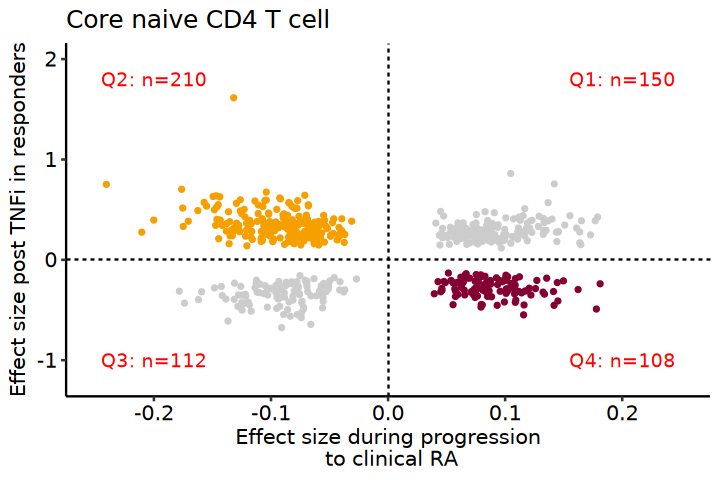

In [ ]:
hightlight_genes <- c(
     "CD99", "CDK4", "CXCR3",
     "FLT3LG", "GZMM", "LTB", "TNFRSF14",
     "IL27RA", "NABP1"
)

cell_type_plot <- "Core naive CD4 T cell"

plot_tnfi_aim3_degs_comparison(tnfi_aim3_degs_comparison_sig, "Core naive CD4 T cell", hightlight_genes, fig_path, proj_name, tnfi_colors)


Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


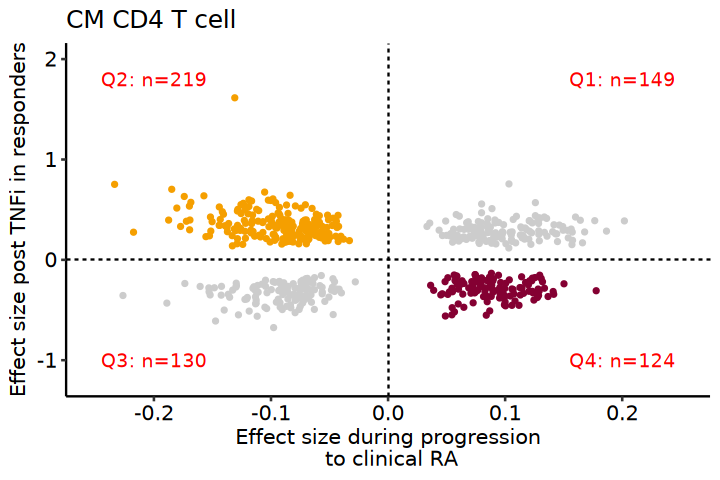

In [ ]:
hightlight_genes <- c(
     "CD99", "CDK4", "CXCR3",
     "FLT3LG", "GZMM", "LTB", "TNFRSF14",
     "IL27RA", "NABP1"
)
plot_tnfi_aim3_degs_comparison(tnfi_aim3_degs_comparison_sig, "CM CD4 T cell", hightlight_genes, fig_path, proj_name, tnfi_colors)


# ouput table S40


In [ ]:
# load the deg table
dds_resp_pair_res_tb <- read_csv(file.path(output_path, paste0(proj_name, "_responder_pre_post_degs.csv"))) %>%
    mutate(treatment = "TNFi", group = "responders")


Rows: 13507 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): gene
dbl (6): baseMean, log2FoldChange, lfcSE, stat, pvalue, q_values

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
dds_resp_pair_res_tb %>% head()


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,q_values,treatment,group
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
WASH7P,282.46281,-0.09281714,0.1579898,-0.5874882,5.568758e-01,0.3940484244,TNFi,responders
MIR6859-2,82.43028,-0.09276267,0.1202438,-0.7714549,4.404374e-01,0.3476168954,TNFi,responders
MIR6859-1,82.43028,-0.09276267,0.1202438,-0.7714549,4.404374e-01,0.3476168954,TNFi,responders
LOC729737,5237.19115,-0.63263934,0.1486966,-4.2545639,2.094568e-05,0.0007281225,TNFi,responders
LOC100132287,56.49217,-0.28869491,0.2721108,-1.0609461,2.887144e-01,0.2736714593,TNFi,responders
LOC100133331,894.93107,-0.36483483,0.1755931,-2.0777282,3.773440e-02,0.0858577496,TNFi,responders


In [ ]:
# load the deg table
dds_nonresp_res_tb <- read_csv(file.path(output_path, paste0(proj_name, "nonresponder_pre_post_degs.csv"))) %>%
    mutate(treatment = "TNFi", group = "non-responders")


Rows: 13502 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): gene
dbl (6): baseMean, log2FoldChange, lfcSE, stat, pvalue, q_values

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
table_s40 <- bind_rows(dds_resp_pair_res_tb, dds_nonresp_res_tb)


In [ ]:
table_s40 %>% write_csv(file.path(output_path, "TableS40_TNFi_deg_results.csv"))
